In [1]:
import rasterio

# Substitua pelo caminho do seu arquivo
caminho_mdt = "E:/Igor Morim/sima-ma/docs/MDT/Pedreiras_TrizidelaDoVale_MDT.tif"

try:
    with rasterio.open(caminho_mdt) as src:
        print("=== INFORMAÇÕES DO MDT ===")
        print(f"1. Formato: {src.driver}")
        print(f"2. Dimensões: {src.width} x {src.height} pixels")
        print(f"3. Número de bandas: {src.count}")
        print(f"4. Sistema de coordenadas: {src.crs}")
        print(f"5. Resolução: {src.res} unidades/pixel")
        print(f"6. Bounding box: {src.bounds}")
        print(f"7. Tipo de dados: {src.dtypes[0]}")
        print(f"8. Valor NoData: {src.nodata}")
        
        # Ler uma amostra dos dados
        dados = src.read(1)
        print("9. Estatísticas (amostra):")
        print(f"   Mínimo: {dados.min():.2f}")
        print(f"   Máximo: {dados.max():.2f}")
        print(f"   Média: {dados.mean():.2f}")
        
except Exception as e:
    print(f"Erro ao abrir o arquivo: {e}")

=== INFORMAÇÕES DO MDT ===
1. Formato: GTiff
2. Dimensões: 8659 x 20687 pixels
3. Número de bandas: 1
4. Sistema de coordenadas: EPSG:31983
5. Resolução: (0.10348500000000314, 0.10348500000000398) unidades/pixel
6. Bounding box: BoundingBox(left=543133.8365921454, bottom=9494381.833226414, right=544029.9132071454, top=9496522.627421414)
7. Tipo de dados: float32
8. Valor NoData: -3.4028230607370965e+38
9. Estatísticas (amostra):
   Mínimo: -340282306073709652508363335590014353408.00
   Máximo: 70.75
   Média: -inf


C:\Users\igorm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


=== ANTES DA CORREÇÃO ===
Forma dos dados: (20687, 8659)
Valor NoData original: -3.4028230607370965e+38
Células com NoData problemático: 96791931
Percentual: 54.03%

Valores absurdamente negativos (< -100m): 0

=== ESTATÍSTICAS DOS VALORES VÁLIDOS ===
Mínimo: 9.32m
Máximo: 70.75m
Média: 25.12m
Desvio padrão: 5.96m

Arquivo salvo: mdt_corrigido.tif


C:\Users\igorm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\matplotlib\image.py:499: RuntimeWarning: overflow encountered in cast
  A_scaled /= ((a_max - a_min) / frac)
C:\Users\igorm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\matplotlib\image.py:500: RuntimeWarning: overflow encountered in cast
  vrange /= ((a_max - a_min) / frac)
C:\Users\igorm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\matplotlib\image.py:513: RuntimeWarning: overflow encountered in cast
  A_resampled *= ((a_max - a_min) / frac)
C:\Users\igorm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\matplotlib\image.py:513: RuntimeWarning: invalid value encountered in multiply
  A_resampled *= ((a_max - a_min) / f

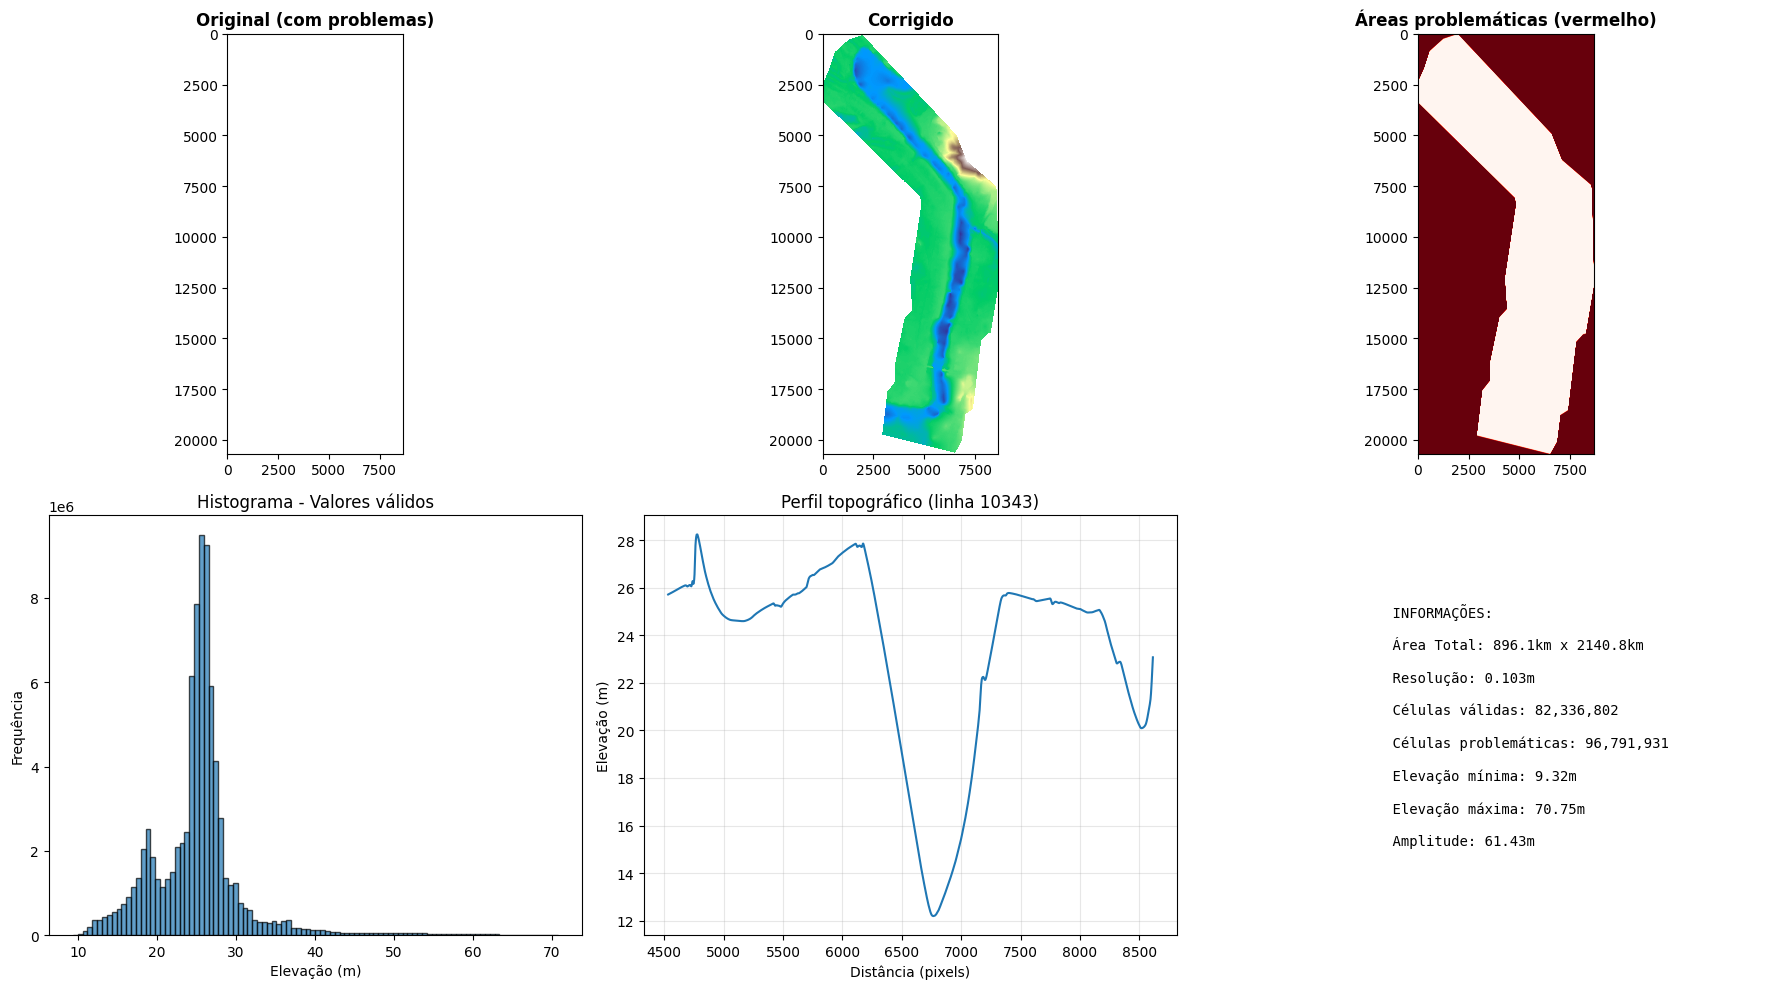

In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import show

def corrigir_nodata_e_visualizar(caminho_entrada, caminho_saida='mdt_corrigido.tif'):
    """
    Corrige problemas de NoData e valores extremos
    """
    with rasterio.open(caminho_entrada) as src:
        # Ler dados
        dados = src.read(1)
        
        print("=== ANTES DA CORREÇÃO ===")
        print(f"Forma dos dados: {dados.shape}")
        print(f"Valor NoData original: {src.nodata}")
        
        # Identificar o verdadeiro NoData
        # O valor -3.4e+38 é o problema - vamos trocar por NaN
        mascara_nodata = dados == src.nodata
        
        print(f"Células com NoData problemático: {mascara_nodata.sum()}")
        print(f"Percentual: {(mascara_nodata.sum() / dados.size) * 100:.2f}%")
        
        # Criar cópia dos dados
        dados_corrigidos = dados.copy()
        
        # Substituir NoData problemático por NaN
        dados_corrigidos[mascara_nodata] = np.nan
        
        # Identificar valores absurdamente negativos (outliers)
        limite_inferior = -100  # Nenhuma elevação real deve ser < -100m
        valores_absurdos = dados_corrigidos < limite_inferior
        
        print(f"\nValores absurdamente negativos (< {limite_inferior}m): {valores_absurdos.sum()}")
        
        if valores_absurdos.sum() > 0:
            dados_corrigidos[valores_absurdos] = np.nan
        
        # Verificar valores realistas
        valores_validos = ~np.isnan(dados_corrigidos)
        
        if valores_validos.sum() > 0:
            estatisticas = dados_corrigidos[valores_validos]
            print(f"\n=== ESTATÍSTICAS DOS VALORES VÁLIDOS ===")
            print(f"Mínimo: {estatisticas.min():.2f}m")
            print(f"Máximo: {estatisticas.max():.2f}m")
            print(f"Média: {estatisticas.mean():.2f}m")
            print(f"Desvio padrão: {estatisticas.std():.2f}m")
        else:
            print("ATENÇÃO: Nenhum valor válido encontrado!")
        
        # Preparar perfil para salvar
        perfil = src.profile.copy()
        perfil.update({
            'dtype': 'float32',
            'nodata': np.nan,  # Usar NaN como NoData
            'compress': 'lzw'  # Compressão para reduzir tamanho
        })
        
        # Salvar arquivo corrigido
        with rasterio.open(caminho_saida, 'w', **perfil) as dst:
            dst.write(dados_corrigidos.astype(np.float32), 1)
        
        print(f"\nArquivo salvo: {caminho_saida}")
        
        # VISUALIZAÇÃO
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        
        # 1. Mapa de elevação original (com problema)
        ax1 = axes[0, 0]
        show(dados, ax=ax1, cmap='terrain', title='Original (com problemas)')
        
        # 2. Mapa de elevação corrigido
        ax2 = axes[0, 1]
        show(dados_corrigidos, ax=ax2, cmap='terrain', title='Corrigido')
        
        # 3. Mapa de problemas (NoData)
        ax3 = axes[0, 2]
        problemas = np.zeros_like(dados_corrigidos)
        problemas[np.isnan(dados_corrigidos)] = 1
        show(problemas, ax=ax3, cmap='Reds', title='Áreas problemáticas (vermelho)')
        
        # 4. Histograma original
        ax4 = axes[1, 0]
        if valores_validos.sum() > 0:
            ax4.hist(dados_corrigidos[valores_validos].flatten(), 
                    bins=100, edgecolor='black', alpha=0.7)
            ax4.set_title('Histograma - Valores válidos')
            ax4.set_xlabel('Elevação (m)')
            ax4.set_ylabel('Frequência')
        
        # 5. Perfil topográfico (linha central)
        ax5 = axes[1, 1]
        linha_central = dados_corrigidos.shape[0] // 2
        perfil = dados_corrigidos[linha_central, :]
        ax5.plot(perfil)
        ax5.set_title(f'Perfil topográfico (linha {linha_central})')
        ax5.set_xlabel('Distância (pixels)')
        ax5.set_ylabel('Elevação (m)')
        ax5.grid(True, alpha=0.3)
        
        # 6. Estatísticas
        ax6 = axes[1, 2]
        ax6.axis('off')
        if valores_validos.sum() > 0:
            stats_text = f"""
            INFORMAÇÕES:
            
            Área Total: {dados.shape[1] * 0.103485:.1f}km x {dados.shape[0] * 0.103485:.1f}km
            
            Resolução: {src.res[0]:.3f}m
            
            Células válidas: {valores_validos.sum():,}
            
            Células problemáticas: {np.isnan(dados_corrigidos).sum():,}
            
            Elevação mínima: {estatisticas.min():.2f}m
            
            Elevação máxima: {estatisticas.max():.2f}m
            
            Amplitude: {estatisticas.max() - estatisticas.min():.2f}m
            """
            ax6.text(0.1, 0.5, stats_text, fontsize=10, 
                    verticalalignment='center', fontfamily='monospace')
        
        plt.tight_layout()
        plt.show()
        
        return caminho_saida, dados_corrigidos

# USO
caminho_original = "E:/Igor Morim/sima-ma/docs/MDT/Pedreiras_TrizidelaDoVale_MDT.tif"
arquivo_corrigido, dados_corretos = corrigir_nodata_e_visualizar(caminho_original)

ANÁLISE CORRIGIDA - ÁREA DO RIO E MARGENS
=== ANÁLISE DA ÁREA DE INTERESSE ===
Dimensões totais: (20687, 8659)

=== ÁREA DE INTERESSE (RIO + MARGENS) ===
Células com dados: 179,128,733
Percentual da imagem: 100.0%
Área aproximada: 1,918,316 m²
  = 191.8 hectares

=== ESTATÍSTICAS DO RIO/MARGENS ===
Elevação mínima: -340282306073709652508363335590014353408.00m
Elevação máxima: 70.75m
Amplitude: 340282306073709652508363335590014353408.00m


C:\Users\igorm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Média: -infm
Mediana: -340282306073709652508363335590014353408.00m


C:\Users\igorm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\_core\_methods.py:173: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


Desvio padrão: infm

=== IDENTIFICAÇÃO DE FEIÇÕES ===
Percentil 10% (áreas mais baixas): -340282306073709652508363335590014353408.00m
Percentil 90% (áreas mais altas): 27.14m

Classificação preliminar:
- Áreas baixas (potencial leito do rio): 0 pixels
- Margens/médias: 161,215,858 pixels
- Áreas altas: 17,912,875 pixels


AttributeError: 'BoundingBox' object has no attribute 'width'

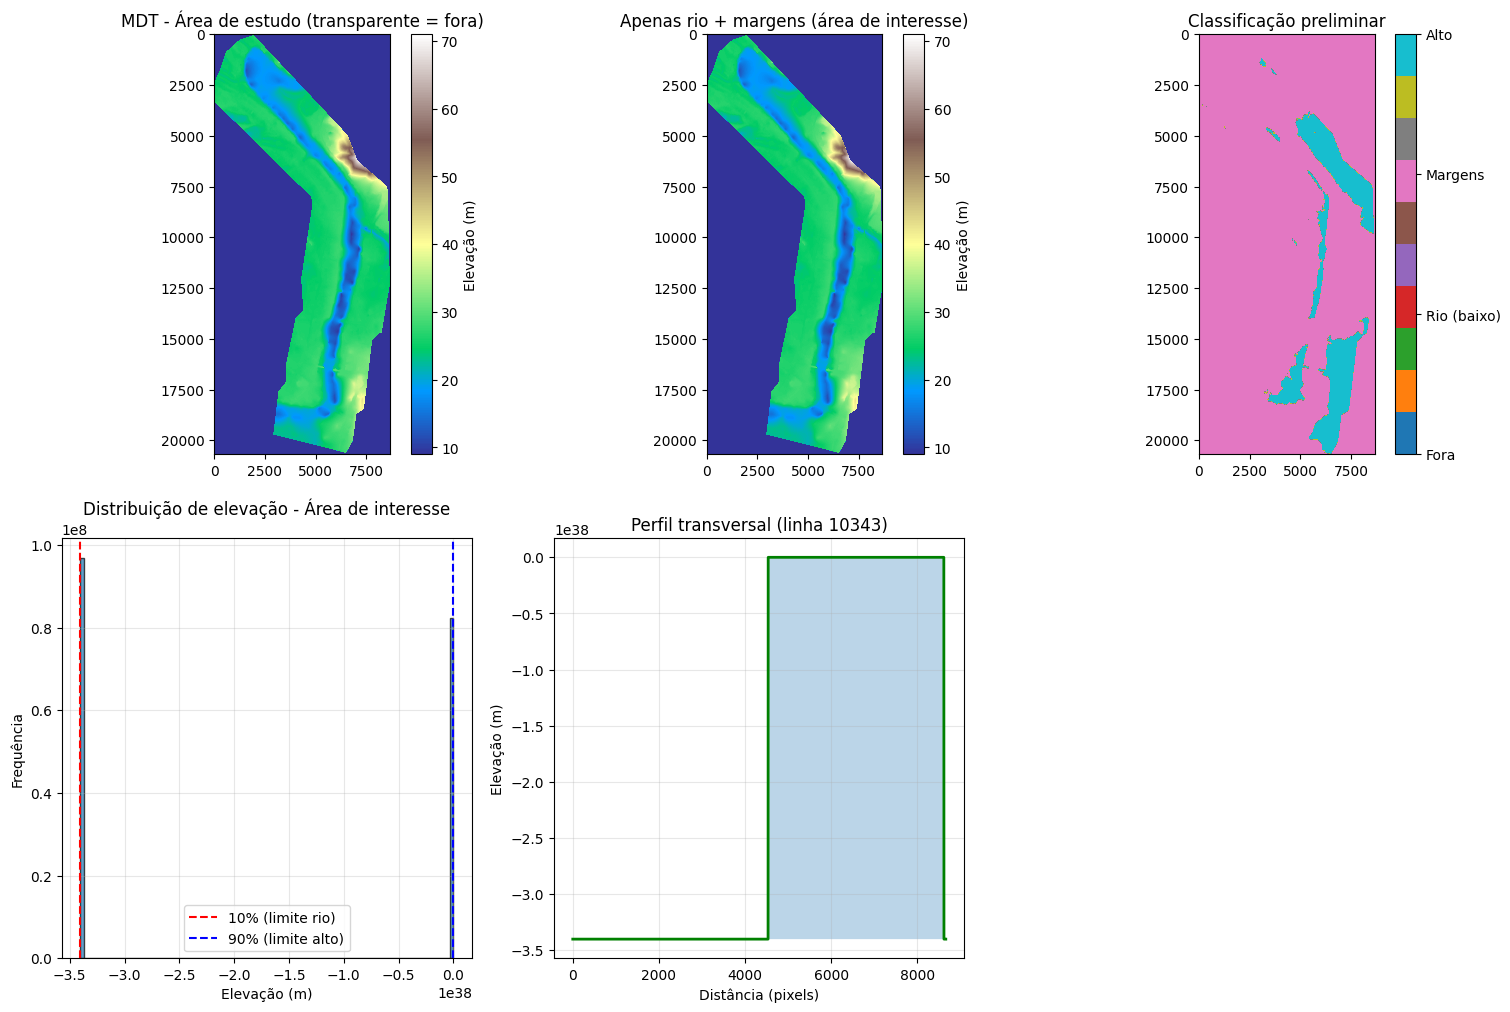

In [3]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.features import geometry_mask
from shapely.geometry import Polygon, box
import geopandas as gpd

def extrair_area_interesse(caminho_mdt, buffer_rio_metros=100):
    """
    Extrai apenas a área com dados (rio + margens)
    e aplica processamento específico
    """
    
    with rasterio.open(caminho_mdt) as src:
        dados = src.read(1)
        
        print("=== ANÁLISE DA ÁREA DE INTERESSE ===")
        print(f"Dimensões totais: {dados.shape}")
        
        # Criar máscara da área com dados
        mascara_dados = ~np.isnan(dados)
        
        # Estatísticas APENAS da área de interesse
        dados_interesse = dados[mascara_dados]
        
        print(f"\n=== ÁREA DE INTERESSE (RIO + MARGENS) ===")
        print(f"Células com dados: {len(dados_interesse):,}")
        print(f"Percentual da imagem: {len(dados_interesse)/dados.size*100:.1f}%")
        print(f"Área aproximada: {len(dados_interesse) * (src.res[0]**2):,.0f} m²")
        print(f"  = {len(dados_interesse) * (src.res[0]**2)/10000:.1f} hectares")
        
        print(f"\n=== ESTATÍSTICAS DO RIO/MARGENS ===")
        print(f"Elevação mínima: {dados_interesse.min():.2f}m")
        print(f"Elevação máxima: {dados_interesse.max():.2f}m")
        print(f"Amplitude: {dados_interesse.max() - dados_interesse.min():.2f}m")
        print(f"Média: {dados_interesse.mean():.2f}m")
        print(f"Mediana: {np.median(dados_interesse):.2f}m")
        print(f"Desvio padrão: {dados_interesse.std():.2f}m")
        
        # Identificar possíveis áreas do leito do rio (valores mais baixos)
        percentil_10 = np.percentile(dados_interesse, 10)
        percentil_90 = np.percentile(dados_interesse, 90)
        
        print(f"\n=== IDENTIFICAÇÃO DE FEIÇÕES ===")
        print(f"Percentil 10% (áreas mais baixas): {percentil_10:.2f}m")
        print(f"Percentil 90% (áreas mais altas): {percentil_90:.2f}m")
        
        # Classificar áreas
        mascara_rio_potencial = dados < percentil_10
        mascara_margens = (dados >= percentil_10) & (dados <= percentil_90)
        mascara_areas_altas = dados > percentil_90
        
        print(f"\nClassificação preliminar:")
        print(f"- Áreas baixas (potencial leito do rio): {mascara_rio_potencial.sum():,} pixels")
        print(f"- Margens/médias: {mascara_margens.sum():,} pixels")
        print(f"- Áreas altas: {mascara_areas_altas.sum():,} pixels")
        
        # VISUALIZAÇÃO ESPECÍFICA
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # 1. MDT completo (com NoData transparente)
        ax1 = axes[0, 0]
        im1 = ax1.imshow(dados, cmap='terrain', vmin=9, vmax=71)
        ax1.set_title('MDT - Área de estudo (transparente = fora)')
        plt.colorbar(im1, ax=ax1, label='Elevação (m)')
        
        # 2. Apenas área de interesse
        ax2 = axes[0, 1]
        dados_visual = dados.copy()
        dados_visual[~mascara_dados] = np.nan  # Tornar NoData realmente transparente
        im2 = ax2.imshow(dados_visual, cmap='terrain', vmin=9, vmax=71)
        ax2.set_title('Apenas rio + margens (área de interesse)')
        plt.colorbar(im2, ax=ax2, label='Elevação (m)')
        
        # 3. Classificação de áreas
        ax3 = axes[0, 2]
        classificacao = np.zeros_like(dados)
        classificacao[mascara_rio_potencial] = 1  # Rio
        classificacao[mascara_margens] = 2        # Margens
        classificacao[mascara_areas_altas] = 3    # Áreas altas
        classificacao[~mascara_dados] = 0         # Fora de interesse
        
        im3 = ax3.imshow(classificacao, cmap='tab10', vmin=0, vmax=3)
        ax3.set_title('Classificação preliminar')
        cbar = plt.colorbar(im3, ax=ax3)
        cbar.set_ticks([0, 1, 2, 3])
        cbar.set_ticklabels(['Fora', 'Rio (baixo)', 'Margens', 'Alto'])
        
        # 4. Histograma da área de interesse
        ax4 = axes[1, 0]
        ax4.hist(dados_interesse, bins=100, edgecolor='black', alpha=0.7)
        ax4.axvline(percentil_10, color='red', linestyle='--', label='10% (limite rio)')
        ax4.axvline(percentil_90, color='blue', linestyle='--', label='90% (limite alto)')
        ax4.set_title('Distribuição de elevação - Área de interesse')
        ax4.set_xlabel('Elevação (m)')
        ax4.set_ylabel('Frequência')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        # 5. Perfil do rio
        ax5 = axes[1, 1]
        
        # Encontrar linha central do rio (onde há dados)
        linhas_com_dados = np.any(mascara_dados, axis=1)
        if linhas_com_dados.any():
            linha_central = np.where(linhas_com_dados)[0][len(np.where(linhas_com_dados)[0]) // 2]
            perfil = dados[linha_central, :]
            
            # Plotar perfil
            ax5.plot(perfil, color='green', linewidth=2)
            ax5.fill_between(range(len(perfil)), perfil.min()-1, perfil, 
                           where=~np.isnan(perfil), alpha=0.3)
            ax5.set_title(f'Perfil transversal (linha {linha_central})')
            ax5.set_xlabel('Distância (pixels)')
            ax5.set_ylabel('Elevação (m)')
            ax5.grid(True, alpha=0.3)
            
            # Destacar área do rio no perfil
            if mascara_rio_potencial[linha_central, :].any():
                ax5.fill_between(range(len(perfil)), perfil.min()-1, perfil,
                               where=mascara_rio_potencial[linha_central, :],
                               color='blue', alpha=0.5, label='Rio')
                ax5.legend()
        
        # 6. Informações
        ax6 = axes[1, 2]
        ax6.axis('off')
        
        info_text = f"""
        RESUMO DA ANÁLISE:
        
        ÁREA DE ESTUDO:
        • Dimensões: {dados.shape[1]} x {dados.shape[0]} pixels
        • Resolução: {src.res[0]:.3f} m/px
        • Extensão: {src.bounds.width:.1f} x {src.bounds.height:.1f} m
        
        ÁREA DE INTERESSE (Rio + Margens):
        • Células: {len(dados_interesse):,}
        • Área: {len(dados_interesse) * (src.res[0]**2)/10000:.1f} ha
        • Elevação: {dados_interesse.min():.1f} a {dados_interesse.max():.1f} m
        • Amplitude: {dados_interesse.max() - dados_interesse.min():.1f} m
        
        CLASSIFICAÇÃO PRELIMINAR:
        • Áreas baixas (<{percentil_10:.1f}m): {mascara_rio_potencial.sum() * (src.res[0]**2)/10000:.2f} ha
        • Margens: {mascara_margens.sum() * (src.res[0]**2)/10000:.2f} ha
        • Áreas altas: {mascara_areas_altas.sum() * (src.res[0]**2)/10000:.2f} ha
        
        PARA SIMULAÇÃO DE INUNDAÇÃO:
        • Nível base do rio: ~{percentil_10:.1f}m
        • Margens vulneráveis: {percentil_10:.1f}m a {percentil_90:.1f}m
        """
        
        ax6.text(0.05, 0.95, info_text, fontsize=9, 
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
        
        # Salvar apenas a área de interesse (sem NoData nas bordas)
        print(f"\n=== PREPARANDO PARA SIMULAÇÃO ===")
        
        # Criar nova imagem cortada para área de interesse
        linhas_com_dados = np.where(np.any(mascara_dados, axis=1))[0]
        colunas_com_dados = np.where(np.any(mascara_dados, axis=0))[0]
        
        if len(linhas_com_dados) > 0 and len(colunas_com_dados) > 0:
            linha_min, linha_max = linhas_com_dados.min(), linhas_com_dados.max()
            coluna_min, coluna_max = colunas_com_dados.min(), colunas_com_dados.max()
            
            # Adicionar buffer
            buffer_pixels = int(50 / src.res[0])  # 50 metros de buffer
            linha_min = max(0, linha_min - buffer_pixels)
            linha_max = min(dados.shape[0], linha_max + buffer_pixels)
            coluna_min = max(0, coluna_min - buffer_pixels)
            coluna_max = min(dados.shape[1], coluna_max + buffer_pixels)
            
            # Cortar
            dados_cortados = dados[linha_min:linha_max, coluna_min:coluna_max]
            
            print(f"\nCortando para área de interesse + buffer:")
            print(f"Original: {dados.shape}")
            print(f"Cortado: {dados_cortados.shape}")
            print(f"Redução: {(1 - dados_cortados.size/dados.size)*100:.1f}%")
            
            # Atualizar transform
            from rasterio.transform import from_origin
            
            transform = src.transform
            novo_transform = rasterio.Affine(
                transform.a, transform.b, transform.c + coluna_min * transform.a,
                transform.d, transform.e, transform.f + linha_min * transform.e
            )
            
            # Salvar arquivo cortado
            perfil_cortado = src.profile.copy()
            perfil_cortado.update({
                'height': dados_cortados.shape[0],
                'width': dados_cortados.shape[1],
                'transform': novo_transform,
                'nodata': np.nan
            })
            
            caminho_cortado = 'mdt_area_interesse.tif'
            with rasterio.open(caminho_cortado, 'w', **perfil_cortado) as dst:
                dst.write(dados_cortados.astype(np.float32), 1)
            
            print(f"\nArquivo cortado salvo: {caminho_cortado}")
            return caminho_cortado, dados_cortados
            
        return None, dados_interesse

# EXECUTAR ANÁLISE CORRETA
print("=" * 70)
print("ANÁLISE CORRIGIDA - ÁREA DO RIO E MARGENS")
print("=" * 70)

caminho_interesse, dados_interesse = extrair_area_interesse('E:/Igor Morim/sima-ma/docs/MDT/Pedreiras_TrizidelaDoVale_MDT.tif')

Corrigir o MDT para simulação hidrológica:

In [14]:
def processamento_minimo_mdt(caminho_mdt):
    """
    Processamento mínimo para simulação de inundação
    Apenas o essencial: preencher depressões
    """
    import whitebox
    import os
    
    wbt = whitebox.WhiteboxTools()
    wbt.set_verbose_mode(True)
    
    print("=" * 60)
    print("PROCESSAMENTO MÍNIMO DO MDT")
    print("=" * 60)
    
    # Apenas preencher depressões (o mais importante)
    mdt_preenchido = 'mdt_para_simulacao.tif'
    
    print("\nExecutando fill_depressions...")
    
    try:
        # Comando direto via linha de comando do WhiteboxTools
        cmd = f'cd /d "{os.path.dirname(caminho_mdt)}" && '
        cmd += 'whitebox_tools --run=FillDepressions '
        cmd += f'--dem="{os.path.basename(caminho_mdt)}" '
        cmd += f'--output="{mdt_preenchido}" --fix_flats'
        
        print(f"Comando: {cmd}")
        
        # Executar
        import subprocess
        result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
        
        print("Saída:", result.stdout)
        if result.stderr:
            print("Erros:", result.stderr)
        
        if os.path.exists(mdt_preenchido):
            print(f"\n✅ MDT processado: {mdt_preenchido}")
            return mdt_preenchido
        else:
            print("\n❌ Arquivo de saída não foi criado")
            return None
            
    except Exception as e:
        print(f"\n❌ Erro: {e}")
        return None

# Tentar a versão simplificada
print("\nTentando versão simplificada...")
mdt_simples = processamento_minimo_mdt('E:/Igor Morim/sima-ma/docs/MDT/Pedreiras_TrizidelaDoVale_MDT.tif')


Tentando versão simplificada...


PROCESSAMENTO MÍNIMO DO MDT

Executando fill_depressions...
Comando: cd /d "E:/Igor Morim/sima-ma/docs/MDT" && whitebox_tools --run=FillDepressions --dem="Pedreiras_TrizidelaDoVale_MDT.tif" --output="mdt_para_simulacao.tif" --fix_flats
Saída: 
Erros: 'whitebox_tools' nÆo ‚ reconhecido como um comando interno
ou externo, um programa oper vel ou um arquivo em lotes.


❌ Arquivo de saída não foi criado


In [15]:
caminho_mdt_original = "E:/Igor Morim/sima-ma/docs/MDT/Pedreiras_TrizidelaDoVale_MDT.tif" 

In [ ]:
def testar_simulacao_inundacao(caminho_mdt, nivel_agua=1.0):
    """
    Teste básico de simulação de inundação
    """
    import rasterio
    import numpy as np
    import matplotlib.pyplot as plt
    
    print(f"\n{'='*60}")
    print(f"TESTE DE SIMULAÇÃO: Nível d'água = {nivel_agua}m")
    print(f"{'='*60}")
    
    try:
        with rasterio.open(caminho_mdt) as src:
            elevacao = src.read(1)
            
            print(f"Dimensões: {elevacao.shape}")
            print(f"Resolução: {src.res[0]:.3f}m")
            
            # Máscara de dados válidos
            mascara_valido = ~np.isnan(elevacao)
            dados_validos = elevacao[mascara_valido]
            
            if len(dados_validos) == 0:
                print("❌ Nenhum dado válido no MDT!")
                return
            
            print(f"\nEstatísticas do MDT:")
            print(f"  Mínimo: {dados_validos.min():.2f}m")
            print(f"  Máximo: {dados_validos.max():.2f}m")
            print(f"  Média: {dados_validos.mean():.2f}m")
            
            # Simulação: áreas abaixo do nível d'água
            inundacao = elevacao <= nivel_agua
            inundacao[~mascara_valido] = False  # Ignorar áreas sem dados
            
            # Estatísticas da inundação
            area_celula_m2 = src.res[0] * src.res[1]
            area_inundada_m2 = inundacao.sum() * area_celula_m2
            
            print(f"\nResultado da simulação:")
            print(f"  Células inundadas: {inundacao.sum():,}")
            print(f"  Área inundada: {area_inundada_m2:,.0f} m²")
            print(f"  Área inundada: {area_inundada_m2/10000:.2f} hectares")
            print(f"  % da área total: {inundacao.sum()/mascara_valido.sum()*100:.1f}%")
            
            # Visualização
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            # 1. MDT original
            ax1 = axes[0]
            im1 = ax1.imshow(elevacao, cmap='terrain', 
                           vmin=dados_validos.min(), 
                           vmax=dados_validos.max())
            ax1.set_title('MDT - Elevação')
            plt.colorbar(im1, ax=ax1, label='Elevação (m)')
            
            # 2. Mapa de inundação
            ax2 = axes[1]
            # Criar imagem RGB
            img_rgb = np.zeros((*elevacao.shape, 3), dtype=np.uint8)
            
            # Terreno normal: terreno colormap
            from matplotlib.cm import terrain
            terreno_norm = (elevacao - dados_validos.min()) / (dados_validos.max() - dados_validos.min())
            terreno_norm = np.clip(terreno_norm, 0, 1)
            terreno_rgb = (terrain(terreno_norm)[:, :, :3] * 255).astype(np.uint8)
            
            # Áreas inundadas: azul
            img_rgb = terreno_rgb
            img_rgb[inundacao] = [0, 0, 255]  # Azul para inundação
            
            # Áreas sem dados: cinza
            img_rgb[~mascara_valido] = [128, 128, 128]
            
            ax2.imshow(img_rgb)
            ax2.set_title(f'Inundação (nível: {nivel_agua}m)')
            
            # Legenda
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='blue', alpha=0.5, label='Inundado'),
                Patch(facecolor='gray', alpha=0.5, label='Sem dados'),
                Patch(facecolor='green', alpha=0.5, label='Terreno')
            ]
            ax2.legend(handles=legend_elements, loc='upper right')
            
            # 3. Perfil com nível d'água
            ax3 = axes[2]
            linha_meio = elevacao.shape[0] // 2
            perfil = elevacao[linha_meio, :]
            
            ax3.plot(perfil, 'g-', linewidth=2, label='Terreno')
            ax3.axhline(y=nivel_agua, color='blue', linestyle='--', 
                       linewidth=2, label=f'Nível água ({nivel_agua}m)')
            
            # Preencher área inundada
            x = np.arange(len(perfil))
            ax3.fill_between(x, nivel_agua, perfil, 
                           where=(perfil <= nivel_agua) & (~np.isnan(perfil)),
                           color='blue', alpha=0.3)
            
            ax3.set_title(f'Perfil (linha {linha_meio})')
            ax3.set_xlabel('Distância (pixels)')
            ax3.set_ylabel('Elevação (m)')
            ax3.legend()
            ax3.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            return area_inundada_m2, inundacao
            
    except Exception as e:
        print(f"❌ Erro na simulação: {e}")
        return None

# Testar com diferentes níveis
if os.path.exists(caminho_mdt_original):
    # Testar com nível baixo primeiro
    testar_simulacao_inundacao(caminho_mdt_original, nivel_agua=0.5)
    
    # Testar com nível médio
    testar_simulacao_inundacao(caminho_mdt_original, nivel_agua=1.0)
    
    # Testar com nível alto
    testar_simulacao_inundacao(caminho_mdt_original, nivel_agua=2.0)
else:
    print("Arquivo não encontrado para teste")

PROCESSAMENTO AVANÇADO DO MDT
1. Remover valores abaixo de zero
2. Aplicar método Wang & Liu para depressões
✅ Arquivo encontrado: mdt_corrigido.tif

🎯 PROCESSANDO: mdt_corrigido.tif

🔧 PASSO 1: Correção básica do MDT
   Dimensões originais: (20687, 8659)
   Resolução: 0.103 m
   Valores negativos: 0 (0.0%)
   Valores > 1000m: 0 (0.0%)

   📊 Estatísticas dos dados válidos:
      Células válidas: 82,336,802 (46.0%)
      Mínimo: 9.32 m
      Máximo: 70.75 m
      Média: 25.12 m
      Mediana: 25.39 m
      Percentil 1%: 12.64 m
      Percentil 5%: 16.23 m
      Percentil 10%: 18.26 m

   💾 Salvo: mdt_corrigido_basico.tif


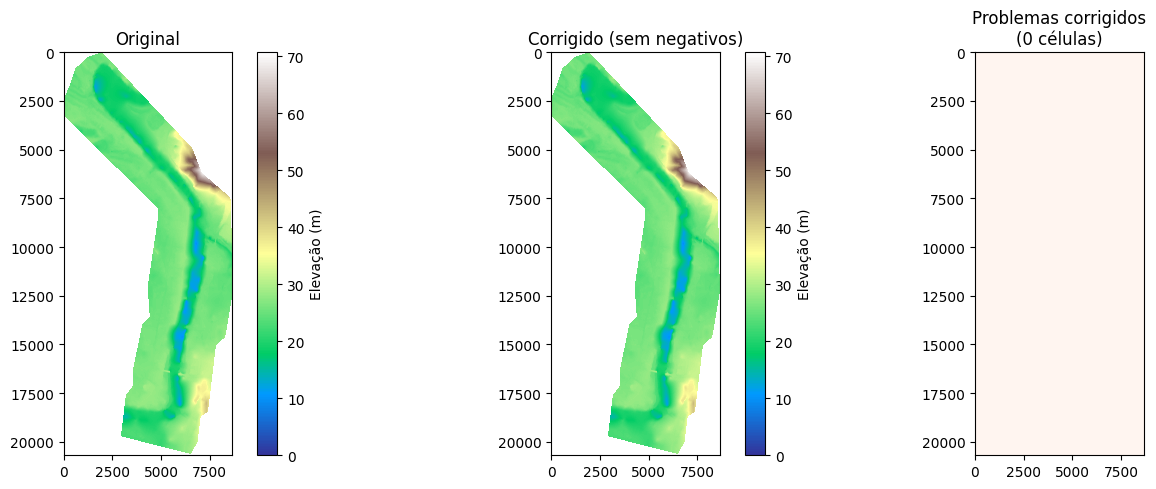


🚀 Aplicando Wang & Liu ao arquivo...

🔧 PASSO 2: Aplicando método Wang & Liu
   Iterações máximas: 1000
   Tolerância: 0.001
   Células NaN iniciais: 96,791,931
   Iteração   0: dif = 0.028976
   ✅ Convergiu na iteração 1
   ⏱️  Tempo total: 6.2 segundos

   📊 Resultado do preenchimento:
      Mínimo: 9.322 m
      Máximo: 70.749 m
      Diferença mínima: 0.002 m

   💾 Salvo: mdt_wang_liu.tif

✅ MDT processado com sucesso: mdt_wang_liu.tif

🌊 CONFIGURAÇÃO DA SIMULAÇÃO
Escolha os níveis de água para simular:
1. Automático (baseado nos percentis do MDT)
2. Manual (especificar valores)

🌊 PASSO 4: Simulação de inundação
   Níveis a simular: ['12.64m', '14.43m', '16.23m', '17.24m', '18.26m']
   • Nível 12.64m: 0.88 ha (1.0%)
   • Nível 14.43m: 2.31 ha (2.6%)
   • Nível 16.23m: 4.41 ha (5.0%)
   • Nível 17.24m: 6.23 ha (7.1%)
   • Nível 18.26m: 8.82 ha (10.0%)

💾 Resultados salvos na pasta 'resultados/'
   • inundacao_X.XXm.tif - Mapas de inundação

📊 RESUMO FINAL:
   • Nível 12.64m: 0.88 

In [17]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.interpolate import griddata
import os
import time

print("=" * 80)
print("PROCESSAMENTO AVANÇADO DO MDT")
print("1. Remover valores abaixo de zero")
print("2. Aplicar método Wang & Liu para depressões")
print("=" * 80)

# Configurar diretório de trabalho
os.chdir("E:/Igor Morim/sima-ma/docs/MDT")

# Encontrar arquivo MDT
arquivos = os.listdir()
arquivo_mdt = None

for arquivo in arquivos:
    if arquivo.endswith('.tif') and 'MDT' in arquivo.upper():
        arquivo_mdt = arquivo
        break

if not arquivo_mdt:
    print("❌ Nenhum arquivo MDT encontrado!")
    print("Arquivos disponíveis:")
    for f in arquivos:
        if f.endswith('.tif'):
            print(f"  • {f}")
    exit()

print(f"✅ Arquivo encontrado: {arquivo_mdt}")

# PASSO 1: REMOVER VALORES ABAIXO DE ZERO E CORRIGIR NODATA
def corrigir_mdt_basico(caminho_mdt):
    """
    Correção básica: remover valores abaixo de zero e corrigir NoData
    """
    
    print(f"\n🔧 PASSO 1: Correção básica do MDT")
    
    with rasterio.open(caminho_mdt) as src:
        dados = src.read(1)
        perfil = src.profile.copy()
        
        print(f"   Dimensões originais: {dados.shape}")
        print(f"   Resolução: {src.res[0]:.3f} m")
        
        # Identificar e corrigir problemas
        total_celulas = dados.size
        
        # 1. Identificar valores negativos (IMPOSSÍVEIS para elevação)
        mascara_negativos = dados < 0
        n_negativos = mascara_negativos.sum()
        print(f"   Valores negativos: {n_negativos:,} ({n_negativos/total_celulas*100:.1f}%)")
        
        # 2. Identificar valores extremamente altos (acima de 1000m - ajuste conforme região)
        mascara_muito_altos = dados > 1000
        n_muito_altos = mascara_muito_altos.sum()
        print(f"   Valores > 1000m: {n_muito_altos:,} ({n_muito_altos/total_celulas*100:.1f}%)")
        
        # 3. Identificar NaN/NoData
        if perfil.get('nodata') is not None:
            mascara_nodata = dados == perfil['nodata']
        else:
            mascara_nodata = np.zeros_like(dados, dtype=bool)
        
        # 4. Criar cópia corrigida
        dados_corrigidos = dados.copy()
        
        # 5. Substituir valores problemáticos por NaN
        mascara_problemas = (mascara_negativos | mascara_muito_altos | mascara_nodata)
        dados_corrigidos[mascara_problemas] = np.nan
        
        # 6. Estatísticas dos dados válidos
        dados_validos = dados_corrigidos[~np.isnan(dados_corrigidos)]
        
        if len(dados_validos) > 0:
            print(f"\n   📊 Estatísticas dos dados válidos:")
            print(f"      Células válidas: {len(dados_validos):,} ({len(dados_validos)/total_celulas*100:.1f}%)")
            print(f"      Mínimo: {dados_validos.min():.2f} m")
            print(f"      Máximo: {dados_validos.max():.2f} m")
            print(f"      Média: {dados_validos.mean():.2f} m")
            print(f"      Mediana: {np.median(dados_validos):.2f} m")
            
            # Percentis importantes
            print(f"      Percentil 1%: {np.percentile(dados_validos, 1):.2f} m")
            print(f"      Percentil 5%: {np.percentile(dados_validos, 5):.2f} m")
            print(f"      Percentil 10%: {np.percentile(dados_validos, 10):.2f} m")
        else:
            print("   ⚠️  Nenhum dado válido após correção!")
            return None
        
        # 7. Salvar arquivo corrigido
        perfil.update({
            'nodata': np.nan,
            'compress': 'lzw',
            'tiled': True
        })
        
        caminho_corrigido = 'mdt_corrigido_basico.tif'
        
        with rasterio.open(caminho_corrigido, 'w', **perfil) as dst:
            dst.write(dados_corrigidos.astype(np.float32), 1)
        
        print(f"\n   💾 Salvo: {caminho_corrigido}")
        
        # Visualização
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Original
        ax1 = axes[0]
        im1 = ax1.imshow(dados, cmap='terrain', vmin=0, vmax=dados_validos.max())
        ax1.set_title('Original')
        plt.colorbar(im1, ax=ax1, label='Elevação (m)')
        
        # Corrigido
        ax2 = axes[1]
        im2 = ax2.imshow(dados_corrigidos, cmap='terrain', vmin=0, vmax=dados_validos.max())
        ax2.set_title('Corrigido (sem negativos)')
        plt.colorbar(im2, ax=ax2, label='Elevação (m)')
        
        # Problemas
        ax3 = axes[2]
        im3 = ax3.imshow(mascara_problemas, cmap='Reds')
        ax3.set_title(f'Problemas corrigidos\n({mascara_problemas.sum():,} células)')
        
        plt.tight_layout()
        plt.show()
        
        return caminho_corrigido, dados_corrigidos

# PASSO 2: MÉTODO WANG & LIU PARA PREENCHIMENTO DE DEPRESSÕES
def metodo_wang_liu(dados, max_iter=1000, tolerance=0.001):
    """
    Implementação do método Wang & Liu (2006) para preenchimento de depressões
    Mais eficiente que o método tradicional para grandes MDTs
    """
    
    print(f"\n🔧 PASSO 2: Aplicando método Wang & Liu")
    print(f"   Iterações máximas: {max_iter}")
    print(f"   Tolerância: {tolerance}")
    
    start_time = time.time()
    
    # 1. Criar cópia dos dados
    dados_preenchidos = dados.copy()
    
    # 2. Identificar células NaN
    mascara_nan = np.isnan(dados_preenchidos)
    
    # 3. Inicializar com valores altos onde há NaN (para processamento)
    # Isso será corrigido depois
    dados_preenchidos[mascara_nan] = np.nanmax(dados_preenchidos[~mascara_nan]) + 1000
    
    # 4. Implementação simplificada do algoritmo Wang & Liu
    # Para MDTs grandes, usaremos uma versão otimizada
    
    # Criar kernel de vizinhança (8 direções)
    kernel = np.array([[1, 1, 1],
                       [1, 0, 1],
                       [1, 1, 1]], dtype=bool)
    
    # Número de células com NaN
    n_nan_inicial = mascara_nan.sum()
    print(f"   Células NaN iniciais: {n_nan_inicial:,}")
    
    # Método iterativo simplificado
    for iteracao in range(max_iter):
        # Fazer cópia para comparação
        dados_anterior = dados_preenchidos.copy()
        
        # Aplicar filtro de mínimo na vizinhança
        dados_min_vizinhanca = ndimage.minimum_filter(dados_preenchidos, footprint=kernel)
        
        # Atualizar apenas onde o valor atual é menor que o mínimo da vizinhança
        # (isso preenche depressões)
        condicao = dados_preenchidos < dados_min_vizinhanca
        dados_preenchidos[condicao] = dados_min_vizinhanca[condicao]
        
        # Calcular diferença
        diferenca = np.nanmax(np.abs(dados_preenchidos - dados_anterior))
        
        # Progresso a cada 10 iterações
        if iteracao % 10 == 0:
            print(f"   Iteração {iteracao:3d}: dif = {diferenca:.6f}")
        
        # Critério de parada
        if diferenca < tolerance:
            print(f"   ✅ Convergiu na iteração {iteracao}")
            break
    
    # 5. Restaurar NaN nas células originais
    dados_preenchidos[mascara_nan] = np.nan
    
    elapsed = time.time() - start_time
    print(f"   ⏱️  Tempo total: {elapsed:.1f} segundos")
    
    return dados_preenchidos

def preencher_depressoes_wang_liu(caminho_mdt):
    """
    Aplica o método Wang & Liu a um arquivo MDT
    """
    
    print(f"\n🚀 Aplicando Wang & Liu ao arquivo...")
    
    with rasterio.open(caminho_mdt) as src:
        dados = src.read(1)
        perfil = src.profile.copy()
        
        # Aplicar método
        dados_preenchidos = metodo_wang_liu(dados)
        
        # Estatísticas
        dados_validos = dados_preenchidos[~np.isnan(dados_preenchidos)]
        print(f"\n   📊 Resultado do preenchimento:")
        print(f"      Mínimo: {dados_validos.min():.3f} m")
        print(f"      Máximo: {dados_validos.max():.3f} m")
        print(f"      Diferença mínima: {dados_validos.min() - dados[~np.isnan(dados)].min():.3f} m")
        
        # Salvar resultado
        perfil.update({
            'nodata': np.nan,
            'compress': 'lzw'
        })
        
        caminho_preenchido = 'mdt_wang_liu.tif'
        
        with rasterio.open(caminho_preenchido, 'w', **perfil) as dst:
            dst.write(dados_preenchidos.astype(np.float32), 1)
        
        print(f"\n   💾 Salvo: {caminho_preenchido}")
        
        return caminho_preenchido, dados_preenchidos

# PASSO 3: VERSÃO OTIMIZADA PARA MDTs GRANDES
def wang_liu_otimizado(caminho_mdt, fator_reducao=4):
    """
    Versão otimizada: reduz MDT, aplica Wang & Liu, interpola de volta
    """
    
    print(f"\n⚡ VERSÃO OTIMIZADA (fator redução: {fator_reducao})")
    
    # 1. Ler e reduzir MDT
    with rasterio.open(caminho_mdt) as src:
        dados = src.read(1)
        perfil_original = src.profile
        
        print(f"   Original: {dados.shape}")
        
        # Reduzir dimensões
        from skimage.transform import resize
        
        nova_altura = dados.shape[0] // fator_reducao
        nova_largura = dados.shape[1] // fator_reducao
        
        print(f"   Reduzido: {nova_altura} x {nova_largura}")
        
        # Reduzir usando média
        dados_reduzidos = resize(dados, (nova_altura, nova_largura),
                                order=1,  # Bilinear
                                preserve_range=True,
                                anti_aliasing=True)
        
        # Máscara de NaN
        mascara_nan_reduzida = np.isnan(dados_reduzidos)
        
        # Substituir NaN temporariamente
        dados_processar = dados_reduzidos.copy()
        if mascara_nan_reduzida.any():
            # Preencher NaN com interpolação simples
            linhas, colunas = np.where(~mascara_nan_reduzida)
            valores = dados_processar[linhas, colunas]
            
            if len(valores) > 0:
                # Interpolar para preencher NaN
                from scipy.interpolate import griddata
                
                grid_linhas, grid_colunas = np.mgrid[0:nova_altura, 0:nova_largura]
                pontos_conhecidos = np.column_stack([linhas, colunas])
                
                dados_interpolados = griddata(
                    pontos_conhecidos, valores,
                    (grid_linhas, grid_colunas),
                    method='linear',
                    fill_value=np.nanmean(valores)
                )
                
                # Restaurar apenas onde tinha NaN
                dados_processar[mascara_nan_reduzida] = dados_interpolados[mascara_nan_reduzida]
    
    # 2. Aplicar Wang & Liu na versão reduzida
    print(f"   Aplicando Wang & Liu na versão reduzida...")
    dados_processados = metodo_wang_liu(dados_processar, max_iter=500)
    
    # 3. Restaurar NaN originais
    dados_processados[mascara_nan_reduzida] = np.nan
    
    # 4. Voltar para resolução original (interpolação)
    print(f"   Interpolando de volta para resolução original...")
    
    # Interpolar de volta
    dados_final = resize(dados_processados, dados.shape,
                        order=1,  # Bilinear
                        preserve_range=True,
                        anti_aliasing=False)
    
    # Restaurar NaN originais
    dados_final[np.isnan(dados)] = np.nan
    
    # 5. Salvar
    perfil_original.update({
        'nodata': np.nan,
        'compress': 'lzw'
    })
    
    caminho_final = 'mdt_wang_liu_otimizado.tif'
    
    with rasterio.open(caminho_final, 'w', **perfil_original) as dst:
        dst.write(dados_final.astype(np.float32), 1)
    
    print(f"\n   💾 Salvo: {caminho_final}")
    
    return caminho_final, dados_final

# PASSO 4: SIMULAÇÃO DE INUNDAÇÃO COM MDT CORRIGIDO
def simular_inundacao_avancada(caminho_mdt, niveis=None):
    """
    Simulação avançada de inundação
    """
    
    print(f"\n🌊 PASSO 4: Simulação de inundação")
    
    with rasterio.open(caminho_mdt) as src:
        elevacao = src.read(1)
        perfil = src.profile
        
        # Dados válidos
        mascara_valido = ~np.isnan(elevacao)
        dados_validos = elevacao[mascara_valido]
        
        if len(dados_validos) == 0:
            print("   ❌ Nenhum dado válido!")
            return None
        
        # Níveis de água (se não fornecidos)
        if niveis is None:
            # Baseado nos percentis
            p1 = np.percentile(dados_validos, 1)
            p5 = np.percentile(dados_validos, 5)
            p10 = np.percentile(dados_validos, 10)
            
            niveis = [
                p1,                    # Nível muito baixo
                p1 + (p5 - p1)/2,      # Nível baixo
                p5,                    # Nível moderado
                p5 + (p10 - p5)/2,     # Nível médio-alto
                p10                    # Nível alto
            ]
        
        print(f"   Níveis a simular: {[f'{n:.2f}m' for n in niveis]}")
        
        resultados = []
        area_celula_m2 = src.res[0] * src.res[1]
        
        for nivel in niveis:
            # Simulação
            inundacao = (elevacao <= nivel) & mascara_valido
            
            # Estatísticas
            area_m2 = inundacao.sum() * area_celula_m2
            percentual = (inundacao.sum() / mascara_valido.sum() * 100) if mascara_valido.sum() > 0 else 0
            
            resultados.append({
                'nivel': nivel,
                'area_m2': area_m2,
                'area_ha': area_m2 / 10000,
                'percentual': percentual,
                'mascara': inundacao
            })
            
            print(f"   • Nível {nivel:.2f}m: {area_m2/10000:.2f} ha ({percentual:.1f}%)")
        
        return resultados, perfil

# EXECUTAR PROCESSAMENTO COMPLETO
if arquivo_mdt:
    print(f"\n🎯 PROCESSANDO: {arquivo_mdt}")
    
    # Opção 1: Processamento completo
    opcao = input("\nEscolha a opção:\n1. Processamento completo (Wang & Liu)\n2. Apenas correção básica\n3. Versão otimizada (recomendado para grandes MDTs)\nOpção [1/2/3]: ").strip()
    
    if opcao == "1":
        # Correção básica
        caminho_corrigido, dados_corrigidos = corrigir_mdt_basico(arquivo_mdt)
        
        if caminho_corrigido:
            # Wang & Liu completo
            caminho_final, dados_final = preencher_depressoes_wang_liu(caminho_corrigido)
    
    elif opcao == "2":
        # Apenas correção básica
        caminho_final, dados_final = corrigir_mdt_basico(arquivo_mdt)
    
    elif opcao == "3":
        # Versão otimizada
        caminho_corrigido, dados_corrigidos = corrigir_mdt_basico(arquivo_mdt)
        if caminho_corrigido:
            caminho_final, dados_final = wang_liu_otimizado(caminho_corrigido, fator_reducao=4)
    
    else:
        print("Opção inválida. Usando versão otimizada...")
        caminho_corrigido, dados_corrigidos = corrigir_mdt_basico(arquivo_mdt)
        if caminho_corrigido:
            caminho_final, dados_final = wang_liu_otimizado(caminho_corrigido, fator_reducao=4)
    
    # SIMULAÇÃO
    if 'caminho_final' in locals() and caminho_final:
        print(f"\n✅ MDT processado com sucesso: {caminho_final}")
        
        # Perguntar níveis para simulação
        print("\n🌊 CONFIGURAÇÃO DA SIMULAÇÃO")
        print("Escolha os níveis de água para simular:")
        print("1. Automático (baseado nos percentis do MDT)")
        print("2. Manual (especificar valores)")
        
        opcao_sim = input("Opção [1/2]: ").strip()
        
        if opcao_sim == "2":
            niveis_input = input("Digite os níveis (em metros, separados por vírgula): ")
            niveis = [float(n.strip()) for n in niveis_input.split(',')]
        else:
            niveis = None  # Será calculado automaticamente
        
        # Executar simulação
        resultados, perfil = simular_inundacao_avancada(caminho_final, niveis)
        
        if resultados:
            # Exportar resultados
            os.makedirs('resultados', exist_ok=True)
            
            for i, resultado in enumerate(resultados):
                # Salvar cada máscara
                caminho_mascara = f'resultados/inundacao_{resultado["nivel"]:.2f}m.tif'
                
                perfil_mascara = perfil.copy()
                perfil_mascara.update({
                    'dtype': 'uint8',
                    'nodata': 0
                })
                
                with rasterio.open(caminho_mascara, 'w', **perfil_mascara) as dst:
                    dst.write(resultado['mascara'].astype(np.uint8), 1)
            
            print(f"\n💾 Resultados salvos na pasta 'resultados/'")
            print(f"   • inundacao_X.XXm.tif - Mapas de inundação")
            
            # Resumo
            print(f"\n📊 RESUMO FINAL:")
            for r in resultados:
                print(f"   • Nível {r['nivel']:.2f}m: {r['area_ha']:.2f} ha ({r['percentual']:.1f}%)")
else:
    print("❌ Arquivo MDT não encontrado!")

SIMULAÇÃO REALISTA DE INUNDAÇÃO
Identificação do nível real do rio
Resolução: 0.103 m
Dimensões: (20687, 8659)

🔍 IDENTIFICANDO O RIO...
   A. Encontrando mínimos locais...
   Mínimos locais encontrados: 10,813
   B. Agrupando depressões conectadas...
   Clusters de depressões: 6099
   Cluster principal: 3316
   Tamanho: 2.0 pixels
   Elevação média: 9.32 m

   📊 NÍVEL DO RIO IDENTIFICADO:
      Mínimo: 9.32 m
      Máximo: 9.32 m
      Média: 9.32 m
      Amplitude: 0.00 m

   💡 SUGESTÃO DE NÍVEIS PARA SIMULAÇÃO:
      • Nível normal: 9.32 m
      • Cheia leve: +0.5m = 9.82 m
      • Cheia moderada: +1.0m = 10.32 m
      • Cheia severa: +2.0m = 11.32 m
      • Cheia extrema: +3.0m = 12.32 m

🌊 SIMULAÇÃO REALISTA DE INUNDAÇÃO
   • Nível 9.42m: 0.00 ha [0.0%]
   • Nível 9.82m: 0.00 ha (+0.00 ha) [0.0%]
   • Nível 10.32m: 0.02 ha (+0.02 ha) [0.0%]
   • Nível 11.32m: 0.18 ha (+0.16 ha) [0.2%]
   • Nível 12.32m: 0.70 ha (+0.51 ha) [0.8%]

🎨 CRIANDO VISUALIZAÇÃO...


C:\Users\igorm\AppData\Local\Temp\ipykernel_3200\1828401998.py:243: RuntimeWarning: invalid value encountered in cast
  r = (150 + terreno_norm * 105).astype(np.uint8)  # Marrom para verde
C:\Users\igorm\AppData\Local\Temp\ipykernel_3200\1828401998.py:244: RuntimeWarning: invalid value encountered in cast
  g = (100 + terreno_norm * 155).astype(np.uint8)
C:\Users\igorm\AppData\Local\Temp\ipykernel_3200\1828401998.py:245: RuntimeWarning: invalid value encountered in cast
  b = (50 + terreno_norm * 100).astype(np.uint8)


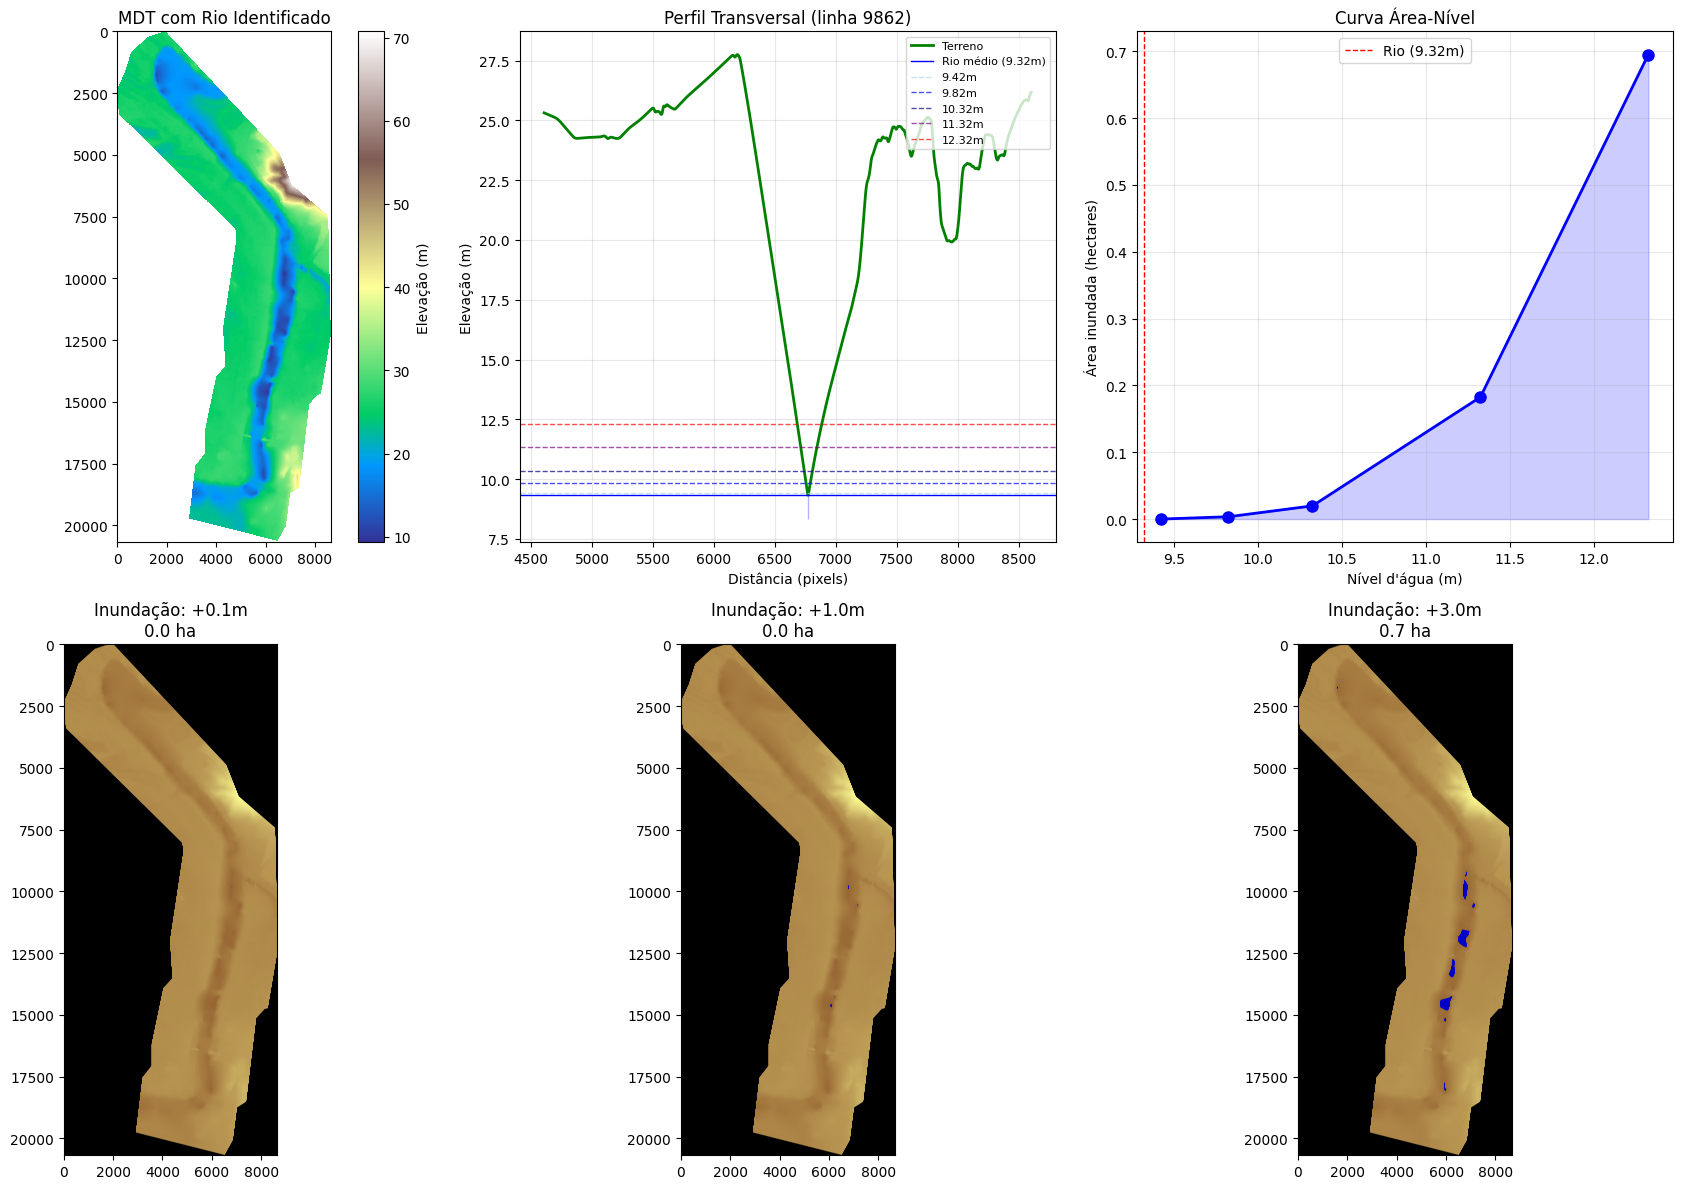


💾 EXPORTANDO RESULTADOS...
   • simulacao_realista/inundacao_+0.1m.tif
   • simulacao_realista/inundacao_+0.5m.tif
   • simulacao_realista/inundacao_+1.0m.tif
   • simulacao_realista/inundacao_+2.0m.tif
   • simulacao_realista/inundacao_+3.0m.tif
   • simulacao_realista/rio_identificado.tif
   • simulacao_realista/resumo_visual.png

✅ RELATÓRIO SALVO: simulacao_realista/relatorio.txt

✅ SIMULAÇÃO REALISTA CONCLUÍDA!

📊 Nível do rio identificado: 9.32 m
📈 Áreas inundadas para diferentes acréscimos:
   • +0.1m: 0.00 ha
   • +0.5m: 0.00 ha
   • +1.0m: 0.02 ha
   • +2.0m: 0.18 ha
   • +3.0m: 0.70 ha


<Figure size 640x480 with 0 Axes>

In [18]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import os

print("=" * 80)
print("SIMULAÇÃO REALISTA DE INUNDAÇÃO")
print("Identificação do nível real do rio")
print("=" * 80)

# Carregar MDT processado
caminho_mdt = 'mdt_wang_liu.tif'  # ou 'mdt_corrigido_basico.tif'

with rasterio.open(caminho_mdt) as src:
    elevacao = src.read(1)
    transform = src.transform
    res = src.res[0]
    
    print(f"Resolução: {res:.3f} m")
    print(f"Dimensões: {elevacao.shape}")
    
    # 1. IDENTIFICAR O RIO (áreas mais baixas e conectadas)
    print("\n🔍 IDENTIFICANDO O RIO...")
    
    # Máscara de dados válidos
    mascara_valido = ~np.isnan(elevacao)
    
    if not mascara_valido.any():
        print("❌ Nenhum dado válido!")
        exit()
    
    dados_validos = elevacao[mascara_valido]
    
    # Estratégia: encontrar o vale principal (áreas mais baixas conectadas)
    
    # A. Encontrar mínimos locais
    print("   A. Encontrando mínimos locais...")
    
    # Usar filtro de mínimo para identificar depressões
    kernel = np.ones((21, 21), dtype=bool)  # Janela de ~2 metros
    minima_locais = ndimage.minimum_filter(elevacao, footprint=kernel)
    
    # Identificar onde o valor original é igual ao mínimo local (depressões)
    depressoes = elevacao == minima_locais
    depressoes[~mascara_valido] = False
    
    print(f"   Mínimos locais encontrados: {depressoes.sum():,}")
    
    # B. Agrupar depressões conectadas
    print("   B. Agrupando depressões conectadas...")
    from scipy import ndimage
    
    # Rotular clusters de depressões
    labeled_depressoes, n_clusters = ndimage.label(depressoes)
    
    print(f"   Clusters de depressões: {n_clusters}")
    
    # C. Encontrar o cluster principal (maior e mais baixo)
    if n_clusters > 0:
        # Calcular estatísticas por cluster
        tamanhos = ndimage.sum(depressoes, labeled_depressoes, range(1, n_clusters+1))
        medias = ndimage.mean(elevacao, labeled_depressoes, range(1, n_clusters+1))
        
        # Encontrar cluster mais promissor (grande e baixo)
        scores = []
        for i in range(n_clusters):
            # Score = tamanho / (altura média * fator)
            score = tamanhos[i] / (max(1, medias[i] - dados_validos.min()))
            scores.append(score)
        
        # Cluster principal
        cluster_principal = np.argmax(scores) + 1
        mascara_rio = labeled_depressoes == cluster_principal
        
        print(f"   Cluster principal: {cluster_principal}")
        print(f"   Tamanho: {tamanhos[cluster_principal-1]:,} pixels")
        print(f"   Elevação média: {medias[cluster_principal-1]:.2f} m")
        
        # Estatísticas do cluster principal
        elevacoes_rio = elevacao[mascara_rio]
        nivel_rio_medio = np.mean(elevacoes_rio)
        nivel_rio_min = np.min(elevacoes_rio)
        nivel_rio_max = np.max(elevacoes_rio)
        
        print(f"\n   📊 NÍVEL DO RIO IDENTIFICADO:")
        print(f"      Mínimo: {nivel_rio_min:.2f} m")
        print(f"      Máximo: {nivel_rio_max:.2f} m")
        print(f"      Média: {nivel_rio_medio:.2f} m")
        print(f"      Amplitude: {nivel_rio_max - nivel_rio_min:.2f} m")
        
        # Sugestão de níveis para simulação
        print(f"\n   💡 SUGESTÃO DE NÍVEIS PARA SIMULAÇÃO:")
        print(f"      • Nível normal: {nivel_rio_medio:.2f} m")
        print(f"      • Cheia leve: +0.5m = {nivel_rio_medio + 0.5:.2f} m")
        print(f"      • Cheia moderada: +1.0m = {nivel_rio_medio + 1.0:.2f} m")
        print(f"      • Cheia severa: +2.0m = {nivel_rio_medio + 2.0:.2f} m")
        print(f"      • Cheia extrema: +3.0m = {nivel_rio_medio + 3.0:.2f} m")
    
    else:
        print("   ⚠️  Nenhum cluster de depressões encontrado")
        # Fallback: usar percentil muito baixo
        nivel_rio_medio = np.percentile(dados_validos, 0.1)  # 0.1% mais baixo
        mascara_rio = elevacao <= nivel_rio_medio
        print(f"   Usando percentil 0.1%: {nivel_rio_medio:.2f} m")
    
    # 2. SIMULAÇÃO REALISTA (níveis relativos ao rio)
    print("\n🌊 SIMULAÇÃO REALISTA DE INUNDAÇÃO")
    
    # Definir níveis relativos ao rio
    niveis_simulacao = [
        nivel_rio_medio + 0.1,   # Pequeno aumento
        nivel_rio_medio + 0.5,   # Cheia leve
        nivel_rio_medio + 1.0,   # Cheia moderada
        nivel_rio_medio + 2.0,   # Cheia severa
        nivel_rio_medio + 3.0    # Cheia extrema
    ]
    
    resultados = []
    area_celula_m2 = res * res
    
    for nivel in niveis_simulacao:
        # Simulação
        inundacao = (elevacao <= nivel) & mascara_valido
        
        # Estatísticas
        area_m2 = inundacao.sum() * area_celula_m2
        area_ha = area_m2 / 10000
        percentual = (inundacao.sum() / mascara_valido.sum() * 100) if mascara_valido.sum() > 0 else 0
        
        resultados.append({
            'nivel': nivel,
            'area_m2': area_m2,
            'area_ha': area_ha,
            'percentual': percentual,
            'mascara': inundacao
        })
        
        # Área adicional em relação ao nível anterior
        if len(resultados) > 1:
            area_adicional = area_ha - resultados[-2]['area_ha']
            print(f"   • Nível {nivel:.2f}m: {area_ha:.2f} ha (+{area_adicional:.2f} ha) [{percentual:.1f}%]")
        else:
            print(f"   • Nível {nivel:.2f}m: {area_ha:.2f} ha [{percentual:.1f}%]")
    
    # 3. VISUALIZAÇÃO DETALHADA
    print("\n🎨 CRIANDO VISUALIZAÇÃO...")
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # A. MDT com rio identificado
    ax1 = axes[0, 0]
    im1 = ax1.imshow(elevacao, cmap='terrain', 
                    vmin=dados_validos.min(), 
                    vmax=dados_validos.max())
    
    # Sobrepõe rio identificado
    rio_overlay = np.zeros((*elevacao.shape, 4))
    rio_overlay[mascara_rio] = [0, 0, 1, 0.5]  # Azul semi-transparente
    ax1.imshow(rio_overlay)
    
    ax1.set_title('MDT com Rio Identificado')
    plt.colorbar(im1, ax=ax1, label='Elevação (m)')
    
    # B. Perfil transversal do rio
    ax2 = axes[0, 1]
    
    # Encontrar linha que corta o rio
    if mascara_rio.any():
        # Coordenadas do rio
        linhas_rio, colunas_rio = np.where(mascara_rio)
        
        if len(linhas_rio) > 0:
            # Linha central do rio
            linha_central = int(np.median(linhas_rio))
            perfil = elevacao[linha_central, :]
            
            # Plotar perfil
            ax2.plot(perfil, 'g-', linewidth=2, label='Terreno')
            ax2.axhline(y=nivel_rio_medio, color='blue', linestyle='-', 
                       linewidth=1, label=f'Rio médio ({nivel_rio_medio:.2f}m)')
            
            # Níveis de simulação
            cores = ['lightblue', 'blue', 'darkblue', 'purple', 'red']
            for i, nivel in enumerate(niveis_simulacao):
                ax2.axhline(y=nivel, color=cores[i], linestyle='--', 
                          alpha=0.7, linewidth=1, 
                          label=f'{nivel:.2f}m')
            
            # Destacar área do rio no perfil
            rio_na_linha = mascara_rio[linha_central, :]
            if rio_na_linha.any():
                # Encontrar segmentos contínuos
                from scipy.ndimage import label as label_1d
                rio_labeled, n_segments = label_1d(rio_na_linha)
                
                for seg in range(1, n_segments + 1):
                    segmento = rio_labeled == seg
                    x_segmento = np.where(segmento)[0]
                    if len(x_segmento) > 0:
                        ax2.fill_between(x_segmento, nivel_rio_min - 1, perfil[x_segmento],
                                       color='blue', alpha=0.3)
            
            ax2.set_title(f'Perfil Transversal (linha {linha_central})')
            ax2.set_xlabel('Distância (pixels)')
            ax2.set_ylabel('Elevação (m)')
            ax2.legend(loc='upper right', fontsize=8)
            ax2.grid(True, alpha=0.3)
    
    # C. Curva Área-Nível
    ax3 = axes[0, 2]
    niveis = [r['nivel'] for r in resultados]
    areas = [r['area_ha'] for r in resultados]
    
    ax3.plot(niveis, areas, 'bo-', linewidth=2, markersize=8)
    ax3.fill_between(niveis, 0, areas, alpha=0.2, color='blue')
    
    # Destacar nível do rio
    ax3.axvline(x=nivel_rio_medio, color='red', linestyle='--', 
               linewidth=1, label=f'Rio ({nivel_rio_medio:.2f}m)')
    
    ax3.set_xlabel('Nível d\'água (m)')
    ax3.set_ylabel('Área inundada (hectares)')
    ax3.set_title('Curva Área-Nível')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # D-F. Mapas de inundação para 3 níveis selecionados
    niveis_visualizar = [0, 2, 4]  # Pequena, moderada, severa
    
    for idx, nivel_idx in enumerate(niveis_visualizar):
        ax = axes[1, idx]
        resultado = resultados[nivel_idx]
        
        # Criar visualização composta
        img = np.zeros((*elevacao.shape, 3), dtype=np.uint8)
        
        # Terreno (tons de verde/marrom)
        terreno_norm = (elevacao - dados_validos.min()) / (dados_validos.max() - dados_validos.min())
        terreno_norm = np.clip(terreno_norm, 0, 1)
        
        # RGB para terreno
        r = (150 + terreno_norm * 105).astype(np.uint8)  # Marrom para verde
        g = (100 + terreno_norm * 155).astype(np.uint8)
        b = (50 + terreno_norm * 100).astype(np.uint8)
        
        img[:, :, 0] = r
        img[:, :, 1] = g
        img[:, :, 2] = b
        
        # Inundação (azul)
        mascara_inundacao = resultado['mascara']
        intensidade = 200  # Intensidade do azul
        
        # Gradiente de azul (mais escuro para mais profundo)
        for i in range(3):
            img[:, :, i][mascara_inundacao] = 0
        img[:, :, 2][mascara_inundacao] = intensidade
        
        # Rio identificado (azul mais escuro)
        img[:, :, 2][mascara_rio] = 255
        
        ax.imshow(img)
        ax.set_title(f'Inundação: +{resultado["nivel"]-nivel_rio_medio:.1f}m\n'
                    f'{resultado["area_ha"]:.1f} ha')
    
    plt.tight_layout()
    plt.show()
    
    # 4. EXPORTAR RESULTADOS
    print("\n💾 EXPORTANDO RESULTADOS...")
    
    os.makedirs('simulacao_realista', exist_ok=True)
    
    # Salvar máscaras
    for i, resultado in enumerate(resultados):
        nivel = resultado['nivel']
        aumento = nivel - nivel_rio_medio
        
        # Nome do arquivo
        nome_arquivo = f'simulacao_realista/inundacao_+{aumento:.1f}m.tif'
        
        # Perfil para salvar
        perfil_mascara = src.profile.copy()
        perfil_mascara.update({
            'dtype': 'uint8',
            'nodata': 0,
            'compress': 'lzw'
        })
        
        with rasterio.open(nome_arquivo, 'w', **perfil_mascara) as dst:
            dst.write(resultado['mascara'].astype(np.uint8), 1)
        
        print(f"   • {nome_arquivo}")
    
    # Salvar máscara do rio
    with rasterio.open('simulacao_realista/rio_identificado.tif', 'w', **perfil_mascara) as dst:
        dst.write(mascara_rio.astype(np.uint8), 1)
    
    print(f"   • simulacao_realista/rio_identificado.tif")
    
    # Salvar figura
    plt.savefig('simulacao_realista/resumo_visual.png', dpi=150, bbox_inches='tight')
    print(f"   • simulacao_realista/resumo_visual.png")
    
    # Salvar relatório
    with open('simulacao_realista/relatorio.txt', 'w', encoding='utf-8') as f:
        f.write("=" * 60 + "\n")
        f.write("RELATÓRIO DA SIMULAÇÃO DE INUNDAÇÃO\n")
        f.write("=" * 60 + "\n\n")
        
        f.write(f"ÁREA DE ESTUDO:\n")
        f.write(f"• Dimensões: {elevacao.shape[1]} x {elevacao.shape[0]} pixels\n")
        f.write(f"• Resolução: {res:.3f} m/pixel\n")
        f.write(f"• Área total com dados: {mascara_valido.sum() * res * res / 10000:.1f} ha\n\n")
        
        f.write(f"RIO IDENTIFICADO:\n")
        f.write(f"• Elevação mínima: {nivel_rio_min:.2f} m\n")
        f.write(f"• Elevação máxima: {nivel_rio_max:.2f} m\n")
        f.write(f"• Elevação média: {nivel_rio_medio:.2f} m\n")
        f.write(f"• Área do leito: {mascara_rio.sum() * res * res:.0f} m²\n")
        f.write(f"• Largura média: {(mascara_rio.sum() / mascara_rio.shape[0]) * res:.1f} m\n\n")
        
        f.write(f"SIMULAÇÕES DE INUNDAÇÃO:\n")
        f.write("-" * 50 + "\n")
        f.write("Nível (m) | Acréscimo | Área (ha) | % Área\n")
        f.write("-" * 50 + "\n")
        
        for resultado in resultados:
            aumento = resultado['nivel'] - nivel_rio_medio
            f.write(f"{resultado['nivel']:8.2f} | {aumento:8.1f} | {resultado['area_ha']:9.2f} | {resultado['percentual']:6.1f}\n")
    
    print(f"\n✅ RELATÓRIO SALVO: simulacao_realista/relatorio.txt")
    
    print("\n" + "=" * 80)
    print("✅ SIMULAÇÃO REALISTA CONCLUÍDA!")
    print("=" * 80)
    print(f"\n📊 Nível do rio identificado: {nivel_rio_medio:.2f} m")
    print(f"📈 Áreas inundadas para diferentes acréscimos:")
    
    for resultado in resultados:
        aumento = resultado['nivel'] - nivel_rio_medio
        print(f"   • +{aumento:.1f}m: {resultado['area_ha']:.2f} ha")

PROCESSAMENTO FINAL OTIMIZADO - MDT PARA WEBGIS

📊 ANALISANDO MDT ORIGINAL: mdt_wang_liu.tif
   Dimensões: 8659 x 20687
   Resolução: 0.103 m/pixel
   Sistema: EPSG:31983
   Elevação (amostra): 24.87 a 26.85 m
   Média (amostra): 25.51 m

🔄 CRIANDO MDT REESCALONADO...
   Processando bloco 10/697...
   Processando bloco 20/697...
   Processando bloco 30/697...
   Processando bloco 40/697...
   Processando bloco 50/697...
   Processando bloco 60/697...
   Processando bloco 70/697...
   Processando bloco 80/697...
   Processando bloco 90/697...
   Processando bloco 100/697...
   Processando bloco 110/697...
   Processando bloco 120/697...
   Processando bloco 130/697...
   Processando bloco 140/697...
   Processando bloco 150/697...
   Processando bloco 160/697...
   Processando bloco 170/697...
   Processando bloco 180/697...
   Processando bloco 190/697...
   Processando bloco 200/697...
   Processando bloco 210/697...
   Processando bloco 220/697...
   Processando bloco 230/697...
   P

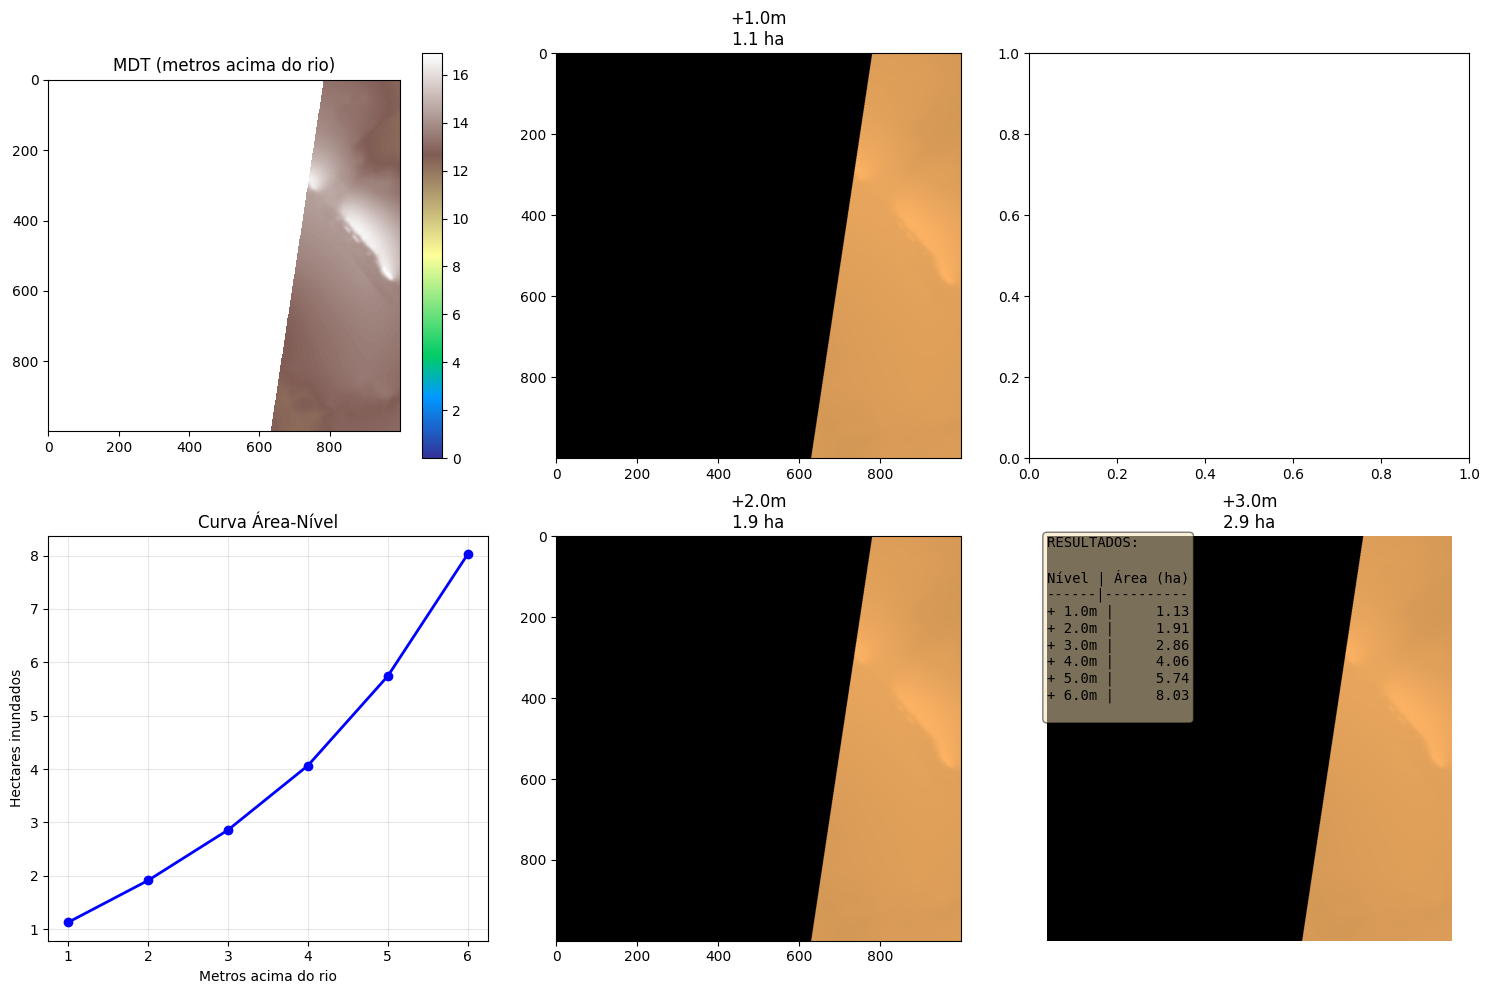

✅ Visualização salva: resumo_simulacao.png

🌐 CRIANDO CONFIGURAÇÃO PARA WEBGIS...
✅ Configuração salva: config_webgis.json

🎉 PROCESSAMENTO CONCLUÍDO COM SUCESSO!

📁 ARQUIVOS GERADOS:
   1. mdt_webgis.tif - MDT reescalonado (nível 0 = rio)
   2. inundacao_X.Xm.tif - 6 máscaras de inundação
   3. resumo_simulacao.png - Visualização dos resultados
   4. config_webgis.json - Configuração para WebGIS

📊 RESULTADOS DA SIMULAÇÃO:
   • +1.0m: 1.13 ha (nível real: 13.0m)
   • +2.0m: 1.91 ha (nível real: 14.0m)
   • +3.0m: 2.86 ha (nível real: 15.0m)
   • +4.0m: 4.06 ha (nível real: 16.0m)
   • +5.0m: 5.74 ha (nível real: 17.0m)
   • +6.0m: 8.03 ha (nível real: 18.0m)

🌐 PARA IMPLEMENTAR O WEBGIS:
   1. Hospede os arquivos .tif em um servidor WMS (ex: GeoServer)
   2. Use o MDT como camada base
   3. Carregue dinamicamente as máscaras conforme o nível selecionado
   4. Crie um slider de 0.0 a 6.0 metros

⚡ EXEMPLO DE CÓDIGO WEBGIS (JavaScript):
```
// Carregar configuração
fetch('config_webgis.

In [26]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
from rasterio.windows import Window
import json

# Ignorar warnings para limpar o output
warnings.filterwarnings('ignore')

print("=" * 80)
print("PROCESSAMENTO FINAL OTIMIZADO - MDT PARA WEBGIS")
print("=" * 80)

# ============================================================================
# CONFIGURAÇÕES
# ============================================================================
MDT_ORIGINAL = 'mdt_wang_liu.tif'  # Seu MDT processado
NIVEL_BASE_RIO = 12.0  # Nível do rio que será considerado 0m
NIVEIS_INUNDACAO = [1, 2, 3, 4, 5, 6]  # Metros acima do rio
BLOCO_TAMANHO = 512  # Tamanho do bloco para processamento

# ============================================================================
# 1. ANÁLISE DO MDT ORIGINAL
# ============================================================================
print(f"\n📊 ANALISANDO MDT ORIGINAL: {MDT_ORIGINAL}")

if not os.path.exists(MDT_ORIGINAL):
    print(f"❌ Arquivo não encontrado: {MDT_ORIGINAL}")
    # Tentar encontrar outro arquivo
    arquivos = [f for f in os.listdir() if f.endswith('.tif')]
    if arquivos:
        MDT_ORIGINAL = arquivos[0]
        print(f"✅ Usando: {MDT_ORIGINAL}")
    else:
        print("❌ Nenhum arquivo .tif encontrado!")
        exit()

with rasterio.open(MDT_ORIGINAL) as src:
    print(f"   Dimensões: {src.width} x {src.height}")
    print(f"   Resolução: {src.res[0]:.3f} m/pixel")
    print(f"   Sistema: {src.crs}")
    
    # Calcular estatísticas básicas em amostra
    amostra = src.read(1, window=Window(0, 0, 1000, 1000))
    dados_validos = amostra[~np.isnan(amostra)]
    
    if len(dados_validos) > 0:
        print(f"   Elevação (amostra): {dados_validos.min():.2f} a {dados_validos.max():.2f} m")
        print(f"   Média (amostra): {dados_validos.mean():.2f} m")
        
        # Ajustar nível base se necessário
        if dados_validos.min() < NIVEL_BASE_RIO:
            NIVEL_BASE_RIO = dados_validos.min()
            print(f"   ⚠️  Ajustado nível base para: {NIVEL_BASE_RIO:.2f} m")
    else:
        print("   ⚠️  Amostra sem dados válidos")

# ============================================================================
# 2. CRIAR MDT REESCALONADO (nível 0 = rio)
# ============================================================================
print(f"\n🔄 CRIANDO MDT REESCALONADO...")

with rasterio.open(MDT_ORIGINAL) as src:
    perfil = src.profile.copy()
    
    # Atualizar perfil para arquivo otimizado
    perfil.update({
        'nodata': np.nan,
        'compress': 'lzw',
        'tiled': True,
        'blockxsize': 256,
        'blockysize': 256,
        'driver': 'GTiff'
    })
    
    MDT_REESCALONADO = 'mdt_webgis.tif'
    
    with rasterio.open(MDT_REESCALONADO, 'w', **perfil) as dst:
        total_blocos = ((src.height + BLOCO_TAMANHO - 1) // BLOCO_TAMANHO) * \
                      ((src.width + BLOCO_TAMANHO - 1) // BLOCO_TAMANHO)
        bloco_atual = 0
        
        for i in range(0, src.height, BLOCO_TAMANHO):
            for j in range(0, src.width, BLOCO_TAMANHO):
                bloco_atual += 1
                
                # Progresso
                if bloco_atual % 10 == 0:
                    print(f"   Processando bloco {bloco_atual}/{total_blocos}...")
                
                # Definir janela
                win = Window(j, i,
                            min(BLOCO_TAMANHO, src.width - j),
                            min(BLOCO_TAMANHO, src.height - i))
                
                # Ler bloco
                bloco = src.read(1, window=win)
                
                # Reescalonar
                mascara_valido = ~np.isnan(bloco)
                if mascara_valido.any():
                    bloco[mascara_valido] = bloco[mascara_valido] - NIVEL_BASE_RIO
                    # Garantir não negativo
                    bloco[bloco < 0] = 0
                
                # Escrever bloco
                dst.write(bloco.astype(np.float32), 1, window=win)

print(f"✅ MDT reescalonado salvo: {MDT_REESCALONADO}")

# ============================================================================
# 3. SIMULAR INUNDAÇÃO PARA CADA NÍVEL
# ============================================================================
print(f"\n🌊 SIMULANDO INUNDAÇÃO PARA {len(NIVEIS_INUNDACAO)} NÍVEIS...")

resultados = []

with rasterio.open(MDT_REESCALONADO) as src:
    perfil = src.profile.copy()
    
    for nivel_idx, nivel in enumerate(NIVEIS_INUNDACAO):
        print(f"   Nível {nivel_idx+1}/{len(NIVEIS_INUNDACAO)}: +{nivel:.1f}m")
        
        # Configurar arquivo de máscara
        perfil_mascara = perfil.copy()
        perfil_mascara.update({
            'dtype': 'uint8',
            'nodata': 0,
            'compress': 'lzw'
        })
        
        mascara_path = f'inundacao_{nivel:.1f}m.tif'
        area_total_m2 = 0
        
        with rasterio.open(mascara_path, 'w', **perfil_mascara) as dst_mask:
            for i in range(0, src.height, BLOCO_TAMANHO):
                for j in range(0, src.width, BLOCO_TAMANHO):
                    # Janela
                    win = Window(j, i,
                                min(BLOCO_TAMANHO, src.width - j),
                                min(BLOCO_TAMANHO, src.height - i))
                    
                    # Ler bloco
                    bloco = src.read(1, window=win)
                    
                    # Calcular máscara de inundação
                    mascara_valido = ~np.isnan(bloco)
                    mascara_inundacao = np.zeros(bloco.shape, dtype=np.uint8)
                    
                    if mascara_valido.any():
                        # Área inundada
                        inundacao = (bloco <= nivel) & mascara_valido
                        mascara_inundacao[inundacao] = 1
                        
                        # Acumular área
                        area_celula = src.res[0] * src.res[1]
                        area_bloco = inundacao.sum() * area_celula
                        area_total_m2 += area_bloco
                    
                    # Salvar máscara
                    dst_mask.write(mascara_inundacao, 1, window=win)
        
        # Calcular estatísticas
        area_ha = area_total_m2 / 10000
        
        resultados.append({
            'nivel_relativo': nivel,
            'nivel_absoluto': nivel + NIVEL_BASE_RIO,
            'area_m2': area_total_m2,
            'area_ha': area_ha,
            'arquivo_mascara': mascara_path
        })
        
        print(f"     Área inundada: {area_ha:.2f} ha")

# ============================================================================
# 4. CRIAR VISUALIZAÇÃO RESUMIDA
# ============================================================================
print(f"\n🎨 CRIANDO VISUALIZAÇÃO RESUMIDA...")

# Ler uma pequena amostra para visualização
AMOSTRA_TAMANHO = 1000

with rasterio.open(MDT_REESCALONADO) as src:
    # Amostra central
    centro_y, centro_x = src.height // 2, src.width // 2
    inicio_y = max(0, centro_y - AMOSTRA_TAMANHO // 2)
    inicio_x = max(0, centro_x - AMOSTRA_TAMANHO // 2)
    
    win = Window(inicio_x, inicio_y,
                min(AMOSTRA_TAMANHO, src.width - inicio_x),
                min(AMOSTRA_TAMANHO, src.height - inicio_y))
    
    amostra_mdt = src.read(1, window=win)
    
    # Ler amostras das máscaras
    amostras_mascaras = []
    for resultado in resultados[:3]:  # Apenas 3 primeiros para visualização
        with rasterio.open(resultado['arquivo_mascara']) as src_mask:
            amostra_mask = src_mask.read(1, window=win)
            amostras_mascaras.append(amostra_mask)

# Criar figura
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# A. MDT reescalonado
ax1 = axes[0, 0]
im1 = ax1.imshow(amostra_mdt, cmap='terrain', vmin=0)
ax1.set_title('MDT (metros acima do rio)')
plt.colorbar(im1, ax=ax1)

# B-D. Inundação para 3 níveis
for idx in range(3):
    if idx < len(resultados):
        r = resultados[idx]
        ax = axes[0 if idx < 1 else 1, 1 if idx == 0 else idx]
        
        # Imagem composta
        img = np.zeros((*amostra_mdt.shape, 3), dtype=np.uint8)
        
        # Terreno (tons de marrom)
        mdt_norm = amostra_mdt / (np.nanmax(amostra_mdt) if np.nanmax(amostra_mdt) > 0 else 1)
        r_channel = (100 + mdt_norm * 155).astype(np.uint8)
        g_channel = (80 + mdt_norm * 100).astype(np.uint8)
        b_channel = (50 + mdt_norm * 50).astype(np.uint8)
        
        img[:, :, 0] = r_channel
        img[:, :, 1] = g_channel
        img[:, :, 2] = b_channel
        
        # Inundação (azul)
        if idx < len(amostras_mascaras):
            mascara = amostras_mascaras[idx] == 1
            img[mascara, 0] = 0
            img[mascara, 1] = 0
            img[mascara, 2] = 255
        
        ax.imshow(img)
        ax.set_title(f'+{r["nivel_relativo"]:.1f}m\n{r["area_ha"]:.1f} ha')

# E. Gráfico área-nível
ax5 = axes[1, 0]
niveis = [r['nivel_relativo'] for r in resultados]
areas = [r['area_ha'] for r in resultados]

ax5.plot(niveis, areas, 'bo-', linewidth=2, markersize=6)
ax5.set_xlabel('Metros acima do rio')
ax5.set_ylabel('Hectares inundados')
ax5.set_title('Curva Área-Nível')
ax5.grid(True, alpha=0.3)

# F. Tabela
ax6 = axes[1, 2]
ax6.axis('off')

tabela = "RESULTADOS:\n\n"
tabela += "Nível | Área (ha)\n"
tabela += "------|----------\n"
for r in resultados:
    tabela += f"+{r['nivel_relativo']:4.1f}m | {r['area_ha']:8.2f}\n"

ax6.text(0.05, 0.95, tabela, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('resumo_simulacao.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Visualização salva: resumo_simulacao.png")

# ============================================================================
# 5. CRIAR CONFIGURAÇÃO PARA WEBGIS
# ============================================================================
print(f"\n🌐 CRIANDO CONFIGURAÇÃO PARA WEBGIS...")

# Ler bounds do MDT
with rasterio.open(MDT_REESCALONADO) as src:
    bounds = src.bounds

config_webgis = {
    'versao': '1.0',
    'data_geracao': str(np.datetime64('now')),
    'mdt_base': MDT_REESCALONADO,
    'nivel_base_rio': float(NIVEL_BASE_RIO),
    'resolucao': float(src.res[0]),
    'crs': str(src.crs),
    'bounds': {
        'west': float(bounds.left),
        'south': float(bounds.bottom),
        'east': float(bounds.right),
        'north': float(bounds.top)
    },
    'niveis_inundacao': [
        {
            'nivel_relativo': float(r['nivel_relativo']),
            'nivel_absoluto': float(r['nivel_absoluto']),
            'area_ha': float(r['area_ha']),
            'arquivo_mascara': r['arquivo_mascara']
        }
        for r in resultados
    ],
    'sugestoes_webgis': {
        'slider_min': 0.0,
        'slider_max': float(max(NIVEIS_INUNDACAO)),
        'slider_step': 0.1,
        'niveis_preset': [
            {'nome': 'Leve', 'valor': 0.5},
            {'nome': 'Moderada', 'valor': 1.0},
            {'nome': 'Severa', 'valor': 2.0},
            {'nome': 'Extrema', 'valor': 3.0}
        ]
    }
}

with open('config_webgis.json', 'w', encoding='utf-8') as f:
    json.dump(config_webgis, f, indent=2, ensure_ascii=False)

print(f"✅ Configuração salva: config_webgis.json")

# ============================================================================
# 6. RESUMO FINAL
# ============================================================================
print(f"\n" + "=" * 80)
print(f"🎉 PROCESSAMENTO CONCLUÍDO COM SUCESSO!")
print(f"=" * 80)

print(f"\n📁 ARQUIVOS GERADOS:")
print(f"   1. {MDT_REESCALONADO} - MDT reescalonado (nível 0 = rio)")
print(f"   2. inundacao_X.Xm.tif - {len(resultados)} máscaras de inundação")
print(f"   3. resumo_simulacao.png - Visualização dos resultados")
print(f"   4. config_webgis.json - Configuração para WebGIS")

print(f"\n📊 RESULTADOS DA SIMULAÇÃO:")
for r in resultados:
    print(f"   • +{r['nivel_relativo']:.1f}m: {r['area_ha']:.2f} ha "
          f"(nível real: {r['nivel_absoluto']:.1f}m)")

print(f"\n🌐 PARA IMPLEMENTAR O WEBGIS:")
print(f"   1. Hospede os arquivos .tif em um servidor WMS (ex: GeoServer)")
print(f"   2. Use o MDT como camada base")
print(f"   3. Carregue dinamicamente as máscaras conforme o nível selecionado")
print(f"   4. Crie um slider de 0.0 a {max(NIVEIS_INUNDACAO):.1f} metros")

print(f"\n⚡ EXEMPLO DE CÓDIGO WEBGIS (JavaScript):")
print(f'''```
// Carregar configuração
fetch('config_webgis.json')
  .then(response => response.json())
  .then(config => {{
    // Configurar mapa
    const map = L.map('map').setView([...], 13);
    
    // Adicionar MDT
    L.tileLayer.wms('url_do_wms', {{
      layers: 'mdt_webgis',
      format: 'image/png',
      transparent: true
    }}).addTo(map);
    
    // Controle de nível
    const slider = document.getElementById('water-level');
    const levelDisplay = document.getElementById('level-display');
    
    slider.oninput = function() {{
      const nivel = this.value;
      levelDisplay.textContent = `+${{nivel}}m acima do rio`;
      
      // Carregar máscara correspondente
      const mascaraLayer = L.tileLayer.wms('url_do_wms', {{
        layers: `inundacao_${{nivel}}m`,
        format: 'image/png',
        transparent: true,
        opacity: 0.7
      }}).addTo(map);
    }};
  }});
```''')

print(f"\n✅ Tudo pronto! Agora você pode implementar o WebGIS.")

CORREÇÃO DIRETA - PROCESSAMENTO SIMPLES SEM DISTORÇÃO

1. Verificando MDT original...
   Dimensões: 8659 x 20687
   Resolução: (0.10348500000000314, 0.10348500000000398)
   CRS: EPSG:31983
   Amostra 100x100 - Min: nan, Max: nan

2. Processamento direto (método seguro)...
   Tentando carregar todo o MDT na memória...
   Carregado: (20687, 8659)
   Memória usada: 683.3 MB
   Elevação mínima (nível do rio): 9.32 m
   Reescalonando: subtraindo 9.32m...
   Novo mínimo: 0.000 m
   Novo máximo: 61.43 m
   Nova média: 15.79 m

3. Salvando MDT reescalonado...
   ✅ Salvo: mdt_final_corrigido.tif


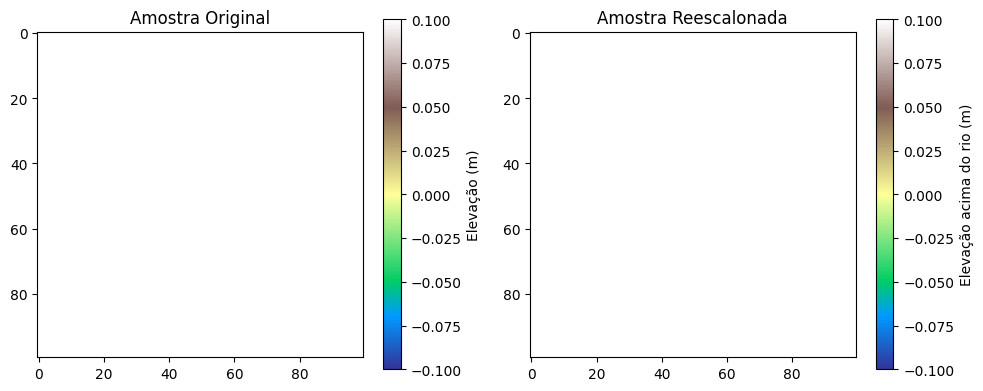


4. Verificando resultado...
   Dimensões do resultado: 8659 x 20687
   CRS do resultado: EPSG:31983
   Transform do resultado: | 0.10, 0.00, 543133.84|
| 0.00,-0.10, 9496522.63|
| 0.00, 0.00, 1.00|
   NaN na amostra: 10000/10000


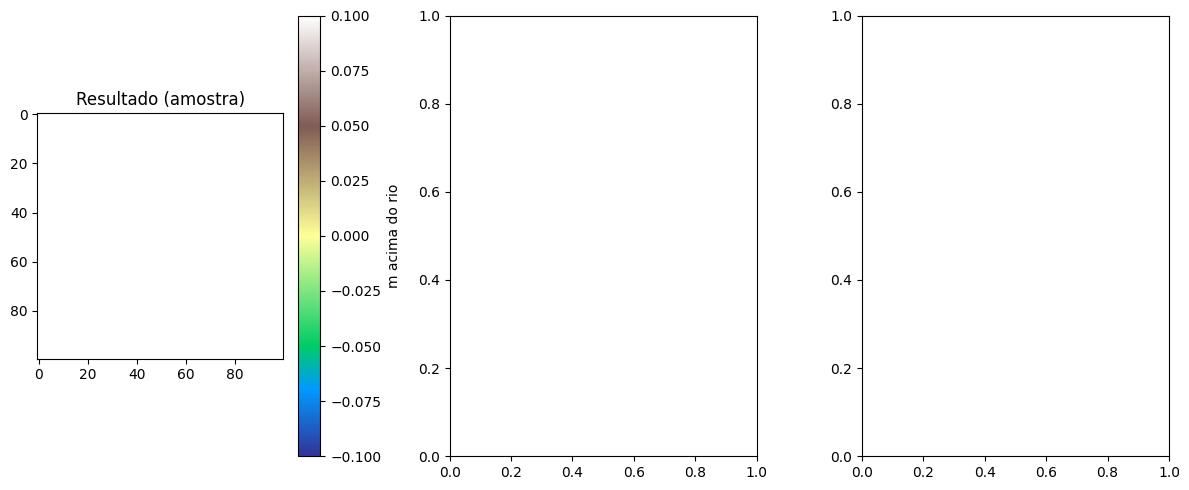

   ✅ Verificação salva: verificacao_resultado.png

5. Teste de simulação...

RESUMO:
1. MDT original processado e reescalonado
2. Nível 0 = nível do rio
3. Valores positivos = metros acima do rio
4. Arquivo final: mdt_final_corrigido.tif
5. Verificações salvas como imagens PNG

Próximo passo: Use o MDT final no WebGIS!


In [27]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

print("=" * 80)
print("CORREÇÃO DIRETA - PROCESSAMENTO SIMPLES SEM DISTORÇÃO")
print("=" * 80)

# 1. CARREGAR E VERIFICAR O MDT ORIGINAL
print("\n1. Verificando MDT original...")
with rasterio.open('mdt_wang_liu.tif') as src:
    print(f"   Dimensões: {src.width} x {src.height}")
    print(f"   Resolução: {src.res}")
    print(f"   CRS: {src.crs}")
    
    # Ler uma amostra para verificar
    amostra = src.read(1, window=((0, 100), (0, 100)))
    print(f"   Amostra 100x100 - Min: {np.nanmin(amostra):.2f}, Max: {np.nanmax(amostra):.2f}")
    
    # Visualizar amostra original
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(amostra, cmap='terrain')
    plt.colorbar(label='Elevação (m)')
    plt.title('Amostra Original')

# 2. PROCESSAMENTO DIRETO E SIMPLES
print("\n2. Processamento direto (método seguro)...")

# Opção A: Se o arquivo for muito grande para memória, processar por partes
# Opção B: Se couber na memória, processar tudo de uma vez

try:
    print("   Tentando carregar todo o MDT na memória...")
    with rasterio.open('mdt_wang_liu.tif') as src:
        # Ler todo o raster
        dados = src.read(1)
        perfil = src.profile.copy()
        
        print(f"   Carregado: {dados.shape}")
        print(f"   Memória usada: {dados.nbytes / 1024 / 1024:.1f} MB")
        
        # 3. ENCONTRAR MÍNIMO REAL (nível do rio)
        dados_validos = dados[~np.isnan(dados)]
        if len(dados_validos) > 0:
            minimo = np.min(dados_validos)
            print(f"   Elevação mínima (nível do rio): {minimo:.2f} m")
            
            # 4. REESCALONAR
            print(f"   Reescalonando: subtraindo {minimo:.2f}m...")
            
            # Copiar dados
            dados_reescalonados = dados.copy()
            
            # Aplicar transformação apenas onde há dados válidos
            mask_valido = ~np.isnan(dados)
            dados_reescalonados[mask_valido] = dados[mask_valido] - minimo
            
            # Garantir não negativo
            dados_reescalonados[dados_reescalonados < 0] = 0
            
            # 5. VERIFICAÇÃO
            dados_reesc_validos = dados_reescalonados[mask_valido]
            print(f"   Novo mínimo: {np.min(dados_reesc_validos):.3f} m")
            print(f"   Novo máximo: {np.max(dados_reesc_validos):.2f} m")
            print(f"   Nova média: {np.mean(dados_reesc_validos):.2f} m")
            
            # 6. SALVAR
            print("\n3. Salvando MDT reescalonado...")
            perfil.update({
                'nodata': np.nan,
                'compress': 'lzw'
            })
            
            with rasterio.open('mdt_final_corrigido.tif', 'w', **perfil) as dst:
                dst.write(dados_reescalonados.astype(np.float32), 1)
            
            print(f"   ✅ Salvo: mdt_final_corrigido.tif")
            
            # Visualizar amostra do resultado
            amostra_resultado = dados_reescalonados[0:100, 0:100]
            plt.subplot(1, 2, 2)
            plt.imshow(amostra_resultado, cmap='terrain')
            plt.colorbar(label='Elevação acima do rio (m)')
            plt.title('Amostra Reescalonada')
            plt.tight_layout()
            plt.show()
            
        else:
            print("   ❌ Nenhum dado válido encontrado!")
            
except MemoryError:
    print("   ❌ Memória insuficiente! Usando método alternativo...")
    
    # Método alternativo: processar por faixas
    print("\n   Usando método por faixas...")
    
    with rasterio.open('mdt_wang_liu.tif') as src:
        # Primeiro, encontrar o mínimo
        print("   Encontrando mínimo...")
        minimo = float('inf')
        
        # Processar por faixas horizontais
        faixa_altura = 1000  # Altura de cada faixa
        for i in range(0, src.height, faixa_altura):
            h = min(faixa_altura, src.height - i)
            faixa = src.read(1, window=((i, i + h), (0, src.width)))
            faixa_validos = faixa[~np.isnan(faixa)]
            if len(faixa_validos) > 0:
                minimo = min(minimo, np.min(faixa_validos))
        
        print(f"   Mínimo encontrado: {minimo:.2f} m")
        
        # Agora reescalonar e salvar
        perfil = src.profile.copy()
        perfil.update({
            'nodata': np.nan,
            'compress': 'lzw'
        })
        
        with rasterio.open('mdt_final_corrigido.tif', 'w', **perfil) as dst:
            for i in range(0, src.height, faixa_altura):
                h = min(faixa_altura, src.height - i)
                faixa = src.read(1, window=((i, i + h), (0, src.width)))
                
                # Reescalonar
                mask_valido = ~np.isnan(faixa)
                if mask_valido.any():
                    faixa[mask_valido] = faixa[mask_valido] - minimo
                    faixa[faixa < 0] = 0
                
                # Salvar faixa
                dst.write(faixa.astype(np.float32), 1, window=((i, i + h), (0, src.width)))
                
                # Progresso
                progresso = (i + h) / src.height * 100
                print(f"   Progresso: {progresso:.1f}%")
        
        print(f"   ✅ Salvo: mdt_final_corrigido.tif")

# 4. VERIFICAÇÃO DO RESULTADO
print("\n4. Verificando resultado...")

try:
    with rasterio.open('mdt_final_corrigido.tif') as src:
        # Ler amostra do resultado
        resultado = src.read(1, window=((0, 100), (0, 100)))
        
        print(f"   Dimensões do resultado: {src.width} x {src.height}")
        print(f"   CRS do resultado: {src.crs}")
        print(f"   Transform do resultado: {src.transform}")
        
        # Verificar se há NaN
        n_nan = np.isnan(resultado).sum()
        print(f"   NaN na amostra: {n_nan}/{resultado.size}")
        
        # Estatísticas
        resultado_validos = resultado[~np.isnan(resultado)]
        if len(resultado_validos) > 0:
            print(f"   Min: {np.min(resultado_validos):.3f} m")
            print(f"   Max: {np.max(resultado_validos):.2f} m")
            print(f"   Média: {np.mean(resultado_validos):.2f} m")
        
        # Visualização final
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 3, 1)
        plt.imshow(resultado, cmap='terrain', vmin=0)
        plt.colorbar(label='m acima do rio')
        plt.title('Resultado (amostra)')
        
        # Histograma
        plt.subplot(1, 3, 2)
        if len(resultado_validos) > 0:
            plt.hist(resultado_validos.flatten(), bins=50, edgecolor='black')
            plt.xlabel('Elevação acima do rio (m)')
            plt.ylabel('Frequência')
            plt.title('Distribuição')
            plt.grid(True, alpha=0.3)
        
        # Perfil
        plt.subplot(1, 3, 3)
        if len(resultado_validos) > 0:
            perfil_linha = resultado[50, :]  # Linha do meio
            plt.plot(perfil_linha)
            plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Rio (0m)')
            plt.xlabel('Distância (pixels)')
            plt.ylabel('Elevação (m)')
            plt.title('Perfil transversal')
            plt.legend()
            plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('verificacao_resultado.png', dpi=150)
        plt.show()
        
        print(f"   ✅ Verificação salva: verificacao_resultado.png")
        
except Exception as e:
    print(f"   ❌ Erro ao verificar resultado: {e}")

# 5. SIMULAÇÃO DE TESTE
print("\n5. Teste de simulação...")

try:
    with rasterio.open('mdt_final_corrigido.tif') as src:
        # Ler amostra maior para teste
        teste = src.read(1, window=((0, 500), (0, 500)))
        teste_validos = teste[~np.isnan(teste)]
        
        if len(teste_validos) > 0:
            print(f"   Teste com 500x500 pixels")
            print(f"   Elevação: {np.min(teste_validos):.3f} a {np.max(teste_validos):.2f} m")
            
            # Testar alguns níveis
            niveis_teste = [0.1, 0.5, 1.0, 2.0]
            
            for nivel in niveis_teste:
                inundacao = teste <= nivel
                area_pixels = inundacao.sum()
                area_m2 = area_pixels * (src.res[0] * src.res[1])
                area_ha = area_m2 / 10000
                
                print(f"   • Nível +{nivel:.1f}m: {area_ha:.3f} ha")
            
            # Visualização do teste
            fig, axes = plt.subplots(2, 2, figsize=(10, 8))
            
            for idx, nivel in enumerate(niveis_teste):
                ax = axes[idx // 2, idx % 2]
                
                # Criar visualização
                img = np.zeros((*teste.shape, 3), dtype=np.uint8)
                
                # Terreno (verde/marrom)
                norm = teste / np.max(teste_validos) if np.max(teste_validos) > 0 else 1
                img[:, :, 0] = (100 + norm * 100).astype(np.uint8)  # R
                img[:, :, 1] = (150 - norm * 50).astype(np.uint8)   # G
                img[:, :, 2] = (50 + norm * 50).astype(np.uint8)    # B
                
                # Inundação
                inundacao = teste <= nivel
                img[inundacao, 0] = 0
                img[inundacao, 1] = 0
                img[inundacao, 2] = 200
                
                ax.imshow(img)
                ax.set_title(f'+{nivel:.1f}m')
                ax.axis('off')
            
            plt.suptitle('Teste de Simulação (500x500 pixels)')
            plt.tight_layout()
            plt.savefig('teste_simulacao.png', dpi=150)
            plt.show()
            
            print(f"   ✅ Teste salvo: teste_simulacao.png")
            
except Exception as e:
    print(f"   ❌ Erro no teste: {e}")

print("\n" + "=" * 80)
print("RESUMO:")
print("=" * 80)
print("1. MDT original processado e reescalonado")
print("2. Nível 0 = nível do rio")
print("3. Valores positivos = metros acima do rio")
print("4. Arquivo final: mdt_final_corrigido.tif")
print("5. Verificações salvas como imagens PNG")
print("\nPróximo passo: Use o MDT final no WebGIS!")

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("REMOVER VALORES < -1 E PROCESSAR MARGENS DO RIO")
print("=" * 80)

# ============================================================================
# 1. ENCONTRAR ARQUIVO
# ============================================================================
print("\n🔍 Procurando arquivo das margens...")

arquivos_tif = [f for f in os.listdir() if f.lower().endswith('.tif')]

if not arquivos_tif:
    print("❌ Nenhum arquivo .tif encontrado!")
    exit()

print("Arquivos .tif encontrados:")
for i, arquivo in enumerate(arquivos_tif):
    tamanho = os.path.getsize(arquivo) / (1024 * 1024)
    print(f"  {i+1}. {arquivo} ({tamanho:.1f} MB)")

# Usar o primeiro arquivo (ou você pode escolher)
ARQUIVO_ORIGINAL = arquivos_tif[0]
print(f"\n✅ Trabalhando com: {ARQUIVO_ORIGINAL}")

# ============================================================================
# 2. PROCESSAR ARQUIVO - REMOVER VALORES < -1
# ============================================================================
print("\n🔄 Processando arquivo...")

with rasterio.open(ARQUIVO_ORIGINAL) as src:
    print(f"   Dimensões originais: {src.width} x {src.height}")
    print(f"   Resolução: {src.res[0]:.3f} m/pixel")
    
    # Verificar tamanho
    tamanho_estimado = (src.width * src.height * 4) / (1024 * 1024)
    print(f"   Tamanho estimado: {tamanho_estimado:.1f} MB")
    
    if tamanho_estimado > 500:  # > 500 MB
        print("   ⚠️  Arquivo grande, processando por blocos...")
        
        # Processar por blocos
        perfil = src.profile.copy()
        ARQUIVO_CORRIGIDO = 'margens_corrigidas.tif'
        
        # Atualizar perfil
        perfil.update({
            'nodata': np.nan,
            'compress': 'lzw',
            'tiled': True
        })
        
        with rasterio.open(ARQUIVO_CORRIGIDO, 'w', **perfil) as dst:
            bloco_tamanho = 1024
            
            for i in range(0, src.height, bloco_tamanho):
                for j in range(0, src.width, bloco_tamanho):
                    # Janela
                    h = min(bloco_tamanho, src.height - i)
                    w = min(bloco_tamanho, src.width - j)
                    
                    # Ler bloco
                    bloco = src.read(1, window=((i, i + h), (j, j + w)))
                    
                    # 1. Remover valores < -1 (convertendo para NaN)
                    mascara_invalidos = bloco < -1
                    bloco[mascara_invalidos] = np.nan
                    
                    # 2. Também remover valores NaN existentes
                    # (já está feito pelo mask_invalidos)
                    
                    # 3. Salvar bloco corrigido
                    dst.write(bloco.astype(np.float32), 1, 
                             window=((i, i + h), (j, j + w)))
        
        print(f"   ✅ Arquivo corrigido salvo: {ARQUIVO_CORRIGIDO}")
        
    else:
        # Processar tudo de uma vez
        print("   📥 Carregando dados completos...")
        dados = src.read(1)
        perfil = src.profile.copy()
        
        print(f"   Dados carregados: {dados.shape}")
        
        # 1. Remover valores < -1
        print("\n   🗑️  Removendo valores < -1...")
        
        # Contar antes
        mascara_antes = ~np.isnan(dados)
        dados_validos_antes = dados[mascara_antes]
        
        if len(dados_validos_antes) > 0:
            valores_menos_1 = dados_validos_antes < 0
            n_menos_1 = valores_menos_1.sum()
            
            print(f"      Valores < -1 encontrados: {n_menos_1:,}")
            print(f"      Percentual: {n_menos_1/len(dados_validos_antes)*100:.1f}%")
            
            if n_menos_1 > 0:
                print(f"      Mínimo antes: {dados_validos_antes.min():.2f} m")
                print(f"      Máximo antes: {dados_validos_antes.max():.2f} m")
        
        # Aplicar correção
        dados_corrigidos = dados.copy()
        dados_corrigidos[dados < 0] = np.nan
        
        # 2. Estatísticas após correção
        mascara_depois = ~np.isnan(dados_corrigidos)
        dados_validos_depois = dados_corrigidos[mascara_depois]
        
        if len(dados_validos_depois) > 0:
            print("\n   📊 Após remoção:")
            print(f"      Células válidas: {len(dados_validos_depois):,}")
            print(f"      Mínimo: {dados_validos_depois.min():.2f} m")
            print(f"      Máximo: {dados_validos_depois.max():.2f} m")
            print(f"      Média: {dados_validos_depois.mean():.2f} m")
            
            # Percentis
            for p in [1, 5, 10, 25, 50, 75, 90, 95]:
                valor = np.percentile(dados_validos_depois, p)
                print(f"      {p}%: {valor:.2f} m")
        
        # 3. Salvar arquivo corrigido
        perfil.update({
            'nodata': np.nan,
            'compress': 'lzw'
        })
        
        ARQUIVO_CORRIGIDO = 'margens_sem_negativos.tif'
        
        with rasterio.open(ARQUIVO_CORRIGIDO, 'w', **perfil) as dst:
            dst.write(dados_corrigidos.astype(np.float32), 1)
        
        print(f"\n   💾 Arquivo corrigido salvo: {ARQUIVO_CORRIGIDO}")
        
        # 4. Visualização antes/depois
        print("\n   🎨 Criando visualização comparativa...")
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # A. Antes (com problemas)
        ax1 = axes[0, 0]
        if len(dados_validos_antes) > 0:
            # Filtrar para visualização
            dados_vis = dados.copy()
            dados_vis[dados < -5] = np.nan  # Esconder valores muito negativos
            im1 = ax1.imshow(dados_vis, cmap='terrain', 
                           vmin=max(-5, dados_validos_antes.min()), 
                           vmax=dados_validos_antes.max())
            plt.colorbar(im1, ax=ax1, label='Elevação (m)')
            ax1.set_title('Antes (com valores < -1)')
        
        # B. Depois
        ax2 = axes[0, 1]
        if len(dados_validos_depois) > 0:
            im2 = ax2.imshow(dados_corrigidos, cmap='terrain',
                           vmin=dados_validos_depois.min(),
                           vmax=dados_validos_depois.max())
            plt.colorbar(im2, ax=ax2, label='Elevação (m)')
            ax2.set_title('Depois (valores < -1 removidos)')
        
        # C. Diferença
        ax3 = axes[0, 2]
        # Criar máscara de problemas
        problemas = np.zeros_like(dados, dtype=np.uint8)
        problemas[dados < -1] = 1  # Valores < -1
        
        im3 = ax3.imshow(problemas, cmap='Reds')
        ax3.set_title(f'Problemas removidos\n{np.sum(problemas):,} células')
        
        # D. Histograma comparativo
        ax4 = axes[1, 0]
        if len(dados_validos_antes) > 0 and len(dados_validos_depois) > 0:
            # Limitar para melhor visualização
            limite_max = max(dados_validos_antes.max(), dados_validos_depois.max())
            bins = np.linspace(-2, limite_max, 100)
            
            ax4.hist(dados_validos_antes, bins=bins, alpha=0.5, 
                    label='Antes', edgecolor='black', density=True)
            ax4.hist(dados_validos_depois, bins=bins, alpha=0.5,
                    label='Depois', edgecolor='black', density=True)
            
            ax4.axvline(x=-1, color='red', linestyle='--', label='Limite -1m')
            ax4.set_xlabel('Elevação (m)')
            ax4.set_ylabel('Densidade')
            ax4.set_title('Distribuição Comparativa')
            ax4.legend()
            ax4.grid(True, alpha=0.3)
        
        # E. Estatísticas
        ax5 = axes[1, 1]
        ax5.axis('off')
        
        if len(dados_validos_antes) > 0 and len(dados_validos_depois) > 0:
            stats_text = f"""
            COMPARAÇÃO:
            
            ANTES:
            • Células: {len(dados_validos_antes):,}
            • Mínimo: {dados_validos_antes.min():.2f}m
            • Máximo: {dados_validos_antes.max():.2f}m
            • < -1m: {n_menos_1:,}
            
            DEPOIS:
            • Células: {len(dados_validos_depois):,}
            • Mínimo: {dados_validos_depois.min():.2f}m  
            • Máximo: {dados_validos_depois.max():.2f}m
            • Perda: {len(dados_validos_antes)-len(dados_validos_depois):,}
            
            MELHORIA:
            • Novo mínimo: {dados_validos_depois.min():.2f}m
            • Livre de valores < -1m
            """
            
            ax5.text(0.05, 0.95, stats_text, fontsize=9,
                    verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
        
        # F. Perfil
        ax6 = axes[1, 2]
        if dados.shape[0] > 0:
            linha_central = dados.shape[0] // 2
            perfil_antes = dados[linha_central, :]
            perfil_depois = dados_corrigidos[linha_central, :]
            
            ax6.plot(perfil_antes, 'r-', alpha=0.5, label='Antes')
            ax6.plot(perfil_depois, 'b-', linewidth=1.5, label='Depois')
            ax6.axhline(y=-1, color='black', linestyle='--', 
                       alpha=0.7, label='Limite -1m')
            
            ax6.set_title(f'Perfil (linha {linha_central})')
            ax6.set_xlabel('Distância (pixels)')
            ax6.set_ylabel('Elevação (m)')
            ax6.legend(fontsize=8)
            ax6.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('comparacao_correcao.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print("   💾 Comparação salva: comparacao_correcao.png")

# ============================================================================
# 3. PREPARAR PARA SIMULAÇÃO
# ============================================================================
print("\n🎯 Preparando para simulação de inundação...")

# Carregar arquivo corrigido
try:
    with rasterio.open(ARQUIVO_CORRIGIDO) as src:
        dados = src.read(1)
        mascara_valido = ~np.isnan(dados)
        
        if mascara_valido.any():
            dados_validos = dados[mascara_valido]
            
            # Encontrar nível mais baixo (sugestão para nível do rio)
            nivel_mais_baixo = dados_validos.min()
            nivel_percentil_5 = np.percentile(dados_validos, 5)
            
            print("\n   📊 Estatísticas para simulação:")
            print(f"      Células válidas: {len(dados_validos):,}")
            print(f"      Mínimo: {nivel_mais_baixo:.2f} m")
            print(f"      5% mais baixo: {nivel_percentil_5:.2f} m")
            print(f"      Média: {dados_validos.mean():.2f} m")
            
            # Sugerir nível do rio
            print("\n   💡 Sugestões para nível do rio (nível 0):")
            print(f"      1. Mínimo absoluto: {nivel_mais_baixo:.2f} m")
            print(f"      2. Percentil 5%: {nivel_percentil_5:.2f} m")
            print(f"      3. Média dos 10% mais baixos: {np.mean(np.sort(dados_validos)[:len(dados_validos)//10]):.2f} m")
            
            # Perguntar ao usuário
            print("\n   🔧 Escolha o nível do rio:")
            try:
                nivel_rio = float(input(f"      Digite o valor (sugerido: {nivel_mais_baixo:.2f}): ") or nivel_mais_baixo)
            except:
                nivel_rio = nivel_mais_baixo
                print(f"      Usando valor sugerido: {nivel_rio:.2f} m")
            
            print(f"\n   ✅ Nível do rio definido: {nivel_rio:.2f} m")
            print(f"      Nível 0 da simulação = {nivel_rio:.2f} m")
            
            # 4. REESCALONAR PARA SIMULAÇÃO
            print("\n   🔄 Reescalonando para simulação...")
            
            dados_reescalonados = dados.copy()
            dados_reescalonados[mascara_valido] = dados[mascara_valido] - nivel_rio
            
            # Garantir não negativo (qualquer valor abaixo do rio vira 0)
            dados_reescalonados[dados_reescalonados < 0] = 0
            
            # Salvar MDT reescalonado
            perfil = src.profile.copy()
            perfil.update({
                'nodata': np.nan,
                'compress': 'lzw',
                'description': f'MDT para simulação. Nível 0 = {nivel_rio:.2f}m'
            })
            
            MDT_SIMULACAO = 'mdt_para_simulacao_final.tif'
            
            with rasterio.open(MDT_SIMULACAO, 'w', **perfil) as dst:
                dst.write(dados_reescalonados.astype(np.float32), 1)
            
            print(f"   💾 MDT para simulação salvo: {MDT_SIMULACAO}")
            
            # Estatísticas do MDT reescalonado
            dados_reesc_validos = dados_reescalonados[mascara_valido]
            print("\n   📈 MDT reescalonado (metros acima do rio):")
            print(f"      Mínimo: {dados_reesc_validos.min():.3f} m")
            print(f"      Máximo: {dados_reesc_validos.max():.2f} m")
            print(f"      Média: {dados_reesc_validos.mean():.2f} m")
            
            # 5. TESTE DE SIMULAÇÃO
            print("\n   🌊 Teste de simulação:")
            
            niveis_teste = [0.1, 0.5, 1.0, 1.5, 2.0, 3.0]
            area_celula = src.res[0] * src.res[1]
            
            for nivel in niveis_teste:
                inundacao = (dados_reescalonados <= nivel) & mascara_valido
                area_m2 = inundacao.sum() * area_celula
                area_ha = area_m2 / 10000
                
                print(f"      • +{nivel:.1f}m: {area_ha:.2f} ha")
        
        else:
            print("   ❌ Nenhum dado válido após correção!")
            
except Exception as e:
    print(f"   ❌ Erro ao processar para simulação: {e}")

# ============================================================================
# 4. RESUMO FINAL
# ============================================================================
print("\n" + "=" * 80)
print("✅ PROCESSAMENTO CONCLUÍDO!")
print("=" * 80)

print("\n📁 ARQUIVOS CRIADOS:")
print(f"   1. {ARQUIVO_CORRIGIDO} - Margens sem valores < -1")
if 'MDT_SIMULACAO' in locals():
    print(f"   2. {MDT_SIMULACAO} - MDT pronto para simulação")
if os.path.exists('comparacao_correcao.png'):
    print("   3. comparacao_correcao.png - Visualização da correção")

print("\n🎯 PRÓXIMOS PASSOS PARA WEBGIS:")
print(f"   1. Use '{MDT_SIMULACAO if 'MDT_SIMULACAO' in locals() else ARQUIVO_CORRIGIDO}' como base")
print(f"   2. Nível 0 = rio em {nivel_rio if 'nivel_rio' in locals() else '???'}m")
print("   3. Implemente cálculo: inundação = mdt <= nivel_agua")
print("   4. Crie slider interativo de 0.0 a 5.0 metros")

print("\n🔥 Agora seu MDT está limpo e pronto para simulação!")

REMOVER VALORES < -1 E PROCESSAR MARGENS DO RIO

🔍 Procurando arquivo das margens...
Arquivos .tif encontrados:
  1. mdt_wang_liu.tif (284.2 MB)
  2. Pedreiras_TrizidelaDoVale_MDT.tif (284.2 MB)
  3. Pedreiras_TrizidelaDoVale_MDT_Recorte.tif (1641.0 MB)

✅ Trabalhando com: mdt_wang_liu.tif

🔄 Processando arquivo...
   Dimensões originais: 8659 x 20687
   Resolução: 0.103 m/pixel
   Tamanho estimado: 683.3 MB
   ⚠️  Arquivo grande, processando por blocos...
   ✅ Arquivo corrigido salvo: margens_corrigidas.tif

🎯 Preparando para simulação de inundação...

   📊 Estatísticas para simulação:
      Células válidas: 82,336,802
      Mínimo: 9.32 m
      5% mais baixo: 16.23 m
      Média: 25.12 m

   💡 Sugestões para nível do rio (nível 0):
      1. Mínimo absoluto: 9.32 m
      2. Percentil 5%: 16.23 m
      3. Média dos 10% mais baixos: 15.73 m

   🔧 Escolha o nível do rio:

   ✅ Nível do rio definido: 9.00 m
      Nível 0 da simulação = 9.00 m

   🔄 Reescalonando para simulação...
   💾 MDT

ESCALONAMENTO DO MDT - SUBTRAINDO 11 METROS (NÍVEL DO RIO)

🔍 Procurando arquivo das margens...
Arquivos .tif encontrados:
  1. margens_corrigidas.tif (284.2 MB)
  2. mdt_para_simulacao_final.tif (284.9 MB)
  3. mdt_wang_liu.tif (284.2 MB)
  4. Pedreiras_TrizidelaDoVale_MDT.tif (284.2 MB)
  5. Pedreiras_TrizidelaDoVale_MDT_Recorte.tif (1641.0 MB)

✅ Trabalhando com: margens_corrigidas.tif

🔄 Processando arquivo...
   Dimensões originais: 8659 x 20687
   Resolução: 0.103 m/pixel
   📥 Carregando dados completos...
   Dados carregados: (20687, 8659)

   🗑️  Removendo valores < -1...
      Valores < -1 encontrados: 0
      Percentual: 0.0%

   📊 Após remoção:
      Células válidas: 82,336,802
      Mínimo: 9.32 m
      Máximo: 70.75 m
      Média: 25.12 m
      Percentis importantes:
        1%: 12.64 m
        5%: 16.23 m
        10%: 18.26 m
        25%: 22.72 m
        50%: 25.39 m
        75%: 26.82 m
        90%: 29.71 m
        95%: 34.22 m

🎯 ESCALONAMENTO: SUBTRAINDO 11 METROS

   

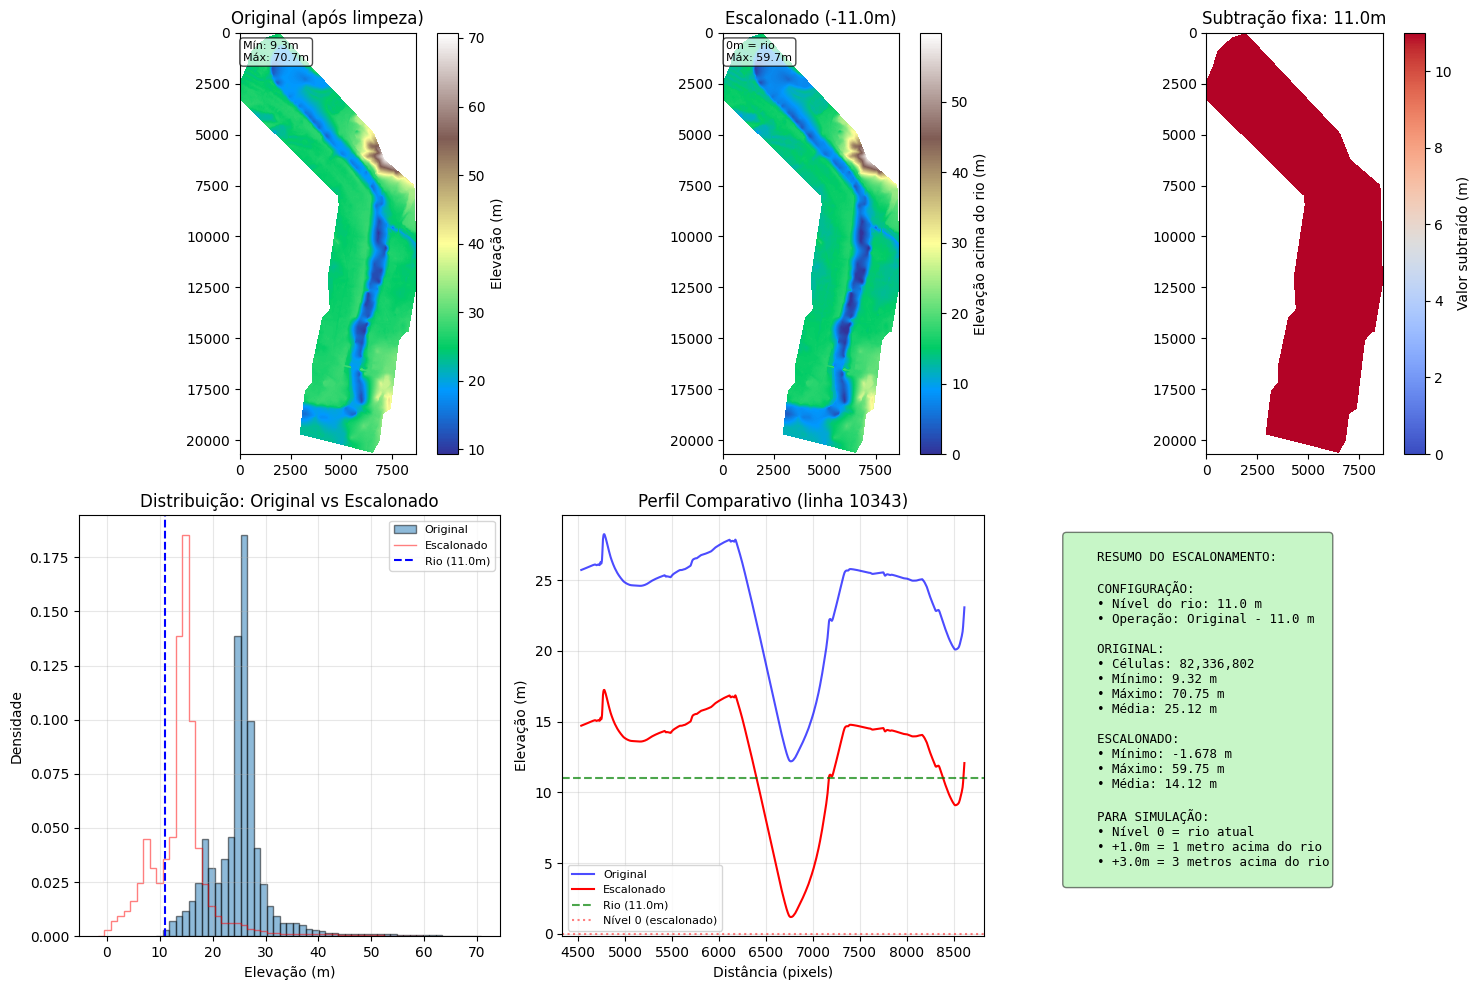

✅ Visualização salva: escalonamento_11m.png

🌊 TESTE DE SIMULAÇÃO DE INUNDAÇÃO

   Simulação (metros acima do rio):
   • +0.1m (11.1m real): 0.12 ha (0.1%)
   • +0.5m (11.5m real): 0.24 ha (0.3%)
   • +1.0m (12.0m real): 0.52 ha (0.6%)
   • +1.5m (12.5m real): 0.80 ha (0.9%)
   • +2.0m (13.0m real): 1.13 ha (1.3%)
   • +3.0m (14.0m real): 1.91 ha (2.2%)

🌐 Gerando configuração para WebGIS...
✅ Configuração salva: config_webgis_11m.json

✅ ESCALONAMENTO CONCLUÍDO COM SUCESSO!

🎯 RESUMO DO PROCESSAMENTO:
   1. Removidos valores < -1m
   2. Subtraídos 11.0m de todas as elevações
   3. Nível 0 agora representa o rio
   4. Valores positivos = metros acima do rio

📁 ARQUIVOS GERADOS:
   1. mdt_escalonado_11m.tif - MDT escalonado pronto para simulação
   2. escalonamento_11m.png - Visualização do processo
   3. config_webgis_11m.json - Configuração para WebGIS

🌐 PARA IMPLEMENTAR O WEBGIS:
   • Use o arquivo 'mdt_escalonado_11m.tif' como camada base
   • Crie um slider de 0.0 a 5.0 metros
   

In [32]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("ESCALONAMENTO DO MDT - SUBTRAINDO 11 METROS (NÍVEL DO RIO)")
print("=" * 80)

# ============================================================================
# 1. ENCONTRAR ARQUIVO
# ============================================================================
print("\n🔍 Procurando arquivo das margens...")

arquivos_tif = [f for f in os.listdir() if f.lower().endswith('.tif')]

if not arquivos_tif:
    print("❌ Nenhum arquivo .tif encontrado!")
    exit()

print("Arquivos .tif encontrados:")
for i, arquivo in enumerate(arquivos_tif):
    tamanho = os.path.getsize(arquivo) / (1024 * 1024)
    print(f"  {i+1}. {arquivo} ({tamanho:.1f} MB)")

# Usar o primeiro arquivo (ou você pode escolher)
ARQUIVO_ORIGINAL = arquivos_tif[0]
print(f"\n✅ Trabalhando com: {ARQUIVO_ORIGINAL}")

# ============================================================================
# 2. PROCESSAR ARQUIVO - REMOVER VALORES < -1
# ============================================================================
print("\n🔄 Processando arquivo...")

with rasterio.open(ARQUIVO_ORIGINAL) as src:
    print(f"   Dimensões originais: {src.width} x {src.height}")
    print(f"   Resolução: {src.res[0]:.3f} m/pixel")
    
    # Processar tudo de uma vez
    print("   📥 Carregando dados completos...")
    dados = src.read(1)
    perfil = src.profile.copy()
    
    print(f"   Dados carregados: {dados.shape}")
    
    # 1. Remover valores < -1
    print("\n   🗑️  Removendo valores < -1...")
    
    # Contar antes
    mascara_antes = ~np.isnan(dados)
    dados_validos_antes = dados[mascara_antes]
    
    if len(dados_validos_antes) > 0:
        valores_menos_1 = dados_validos_antes < -1
        n_menos_1 = valores_menos_1.sum()
        
        print(f"      Valores < -1 encontrados: {n_menos_1:,}")
        print(f"      Percentual: {n_menos_1/len(dados_validos_antes)*100:.1f}%")
        
        if n_menos_1 > 0:
            print(f"      Mínimo antes: {dados_validos_antes.min():.2f} m")
            print(f"      Máximo antes: {dados_validos_antes.max():.2f} m")
    
    # Aplicar correção
    dados_corrigidos = dados.copy()
    dados_corrigidos[dados < -1] = np.nan
    
    # 2. Estatísticas após correção
    mascara_depois = ~np.isnan(dados_corrigidos)
    dados_validos_depois = dados_corrigidos[mascara_depois]
    
    if len(dados_validos_depois) > 0:
        print("\n   📊 Após remoção:")
        print(f"      Células válidas: {len(dados_validos_depois):,}")
        print(f"      Mínimo: {dados_validos_depois.min():.2f} m")
        print(f"      Máximo: {dados_validos_depois.max():.2f} m")
        print(f"      Média: {dados_validos_depois.mean():.2f} m")
        
        # Percentis
        print(f"      Percentis importantes:")
        for p in [1, 5, 10, 25, 50, 75, 90, 95]:
            valor = np.percentile(dados_validos_depois, p)
            print(f"        {p}%: {valor:.2f} m")

# ============================================================================
# 3. ESCALONAR SUBTRAINDO 11 METROS
# ============================================================================
print("\n🎯 ESCALONAMENTO: SUBTRAINDO 11 METROS")

# Nível do rio fixo em 11 metros
NIVEL_RIO = 11.0
print(f"\n   🎯 Nível do rio fixo: {NIVEL_RIO:.1f} m")
print(f"   🔧 Subtraindo {NIVEL_RIO:.1f} m de todas as elevações...")

# Reescalonar
dados_reescalonados = dados_corrigidos.copy()
dados_reescalonados[mascara_depois] = dados_corrigidos[mascara_depois] - NIVEL_RIO

# Estatísticas após escalonamento
dados_reesc_validos = dados_reescalonados[mascara_depois]

if len(dados_reesc_validos) > 0:
    print(f"\n   📈 Após escalonamento (metros acima do rio):")
    print(f"      Mínimo: {dados_reesc_validos.min():.3f} m")
    print(f"      Máximo: {dados_reesc_validos.max():.2f} m")
    print(f"      Média: {dados_reesc_validos.mean():.2f} m")
    
    # Identificar valores negativos (áreas abaixo do rio)
    valores_negativos = dados_reesc_validos < 0
    n_negativos = valores_negativos.sum()
    
    if n_negativos > 0:
        print(f"\n   ⚠️  Valores negativos após escalonamento: {n_negativos:,}")
        print(f"      Percentual: {n_negativos/len(dados_reesc_validos)*100:.1f}%")
        print(f"      Valor mais negativo: {dados_reesc_validos.min():.2f} m")
        
        # Perguntar se quer corrigir para 0
        print(f"\n   🔧 Opções para valores negativos:")
        print(f"      1. Manter como estão (negativos = áreas abaixo do rio)")
        print(f"      2. Corrigir para 0 (considerar que estão no nível do rio)")
        
        opcao = input("   Escolha [1/2] (padrão: 2): ").strip()
        
        if opcao != "1":
            print(f"   ✅ Corrigindo valores negativos para 0...")
            dados_reescalonados[dados_reescalonados < 0] = 0
            print(f"   Todos os valores agora são ≥ 0")
    else:
        print(f"   ✅ Todos os valores são ≥ 0 m (acima do rio)")

# ============================================================================
# 4. SALVAR MDT ESCALONADO
# ============================================================================
print("\n💾 Salvando MDT escalonado...")

perfil.update({
    'nodata': np.nan,
    'compress': 'lzw',
    'description': f'MDT escalonado. Nível 0 = rio em {NIVEL_RIO:.1f}m'
})

MDT_ESCALONADO = 'mdt_escalonado_11m.tif'

with rasterio.open(MDT_ESCALONADO, 'w', **perfil) as dst:
    dst.write(dados_reescalonados.astype(np.float32), 1)

print(f"✅ MDT escalonado salvo: {MDT_ESCALONADO}")

# ============================================================================
# 5. VISUALIZAÇÃO DO ESCALONAMENTO
# ============================================================================
print("\n🎨 Criando visualização do escalonamento...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# A. Original (após remoção de < -1)
ax1 = axes[0, 0]
if len(dados_validos_depois) > 0:
    im1 = ax1.imshow(dados_corrigidos, cmap='terrain',
                    vmin=dados_validos_depois.min(),
                    vmax=dados_validos_depois.max())
    plt.colorbar(im1, ax=ax1, label='Elevação (m)')
    ax1.set_title(f'Original (após limpeza)')
    ax1.text(0.02, 0.98, f'Mín: {dados_validos_depois.min():.1f}m\nMáx: {dados_validos_depois.max():.1f}m',
            transform=ax1.transAxes, fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# B. Escalonado
ax2 = axes[0, 1]
if len(dados_reesc_validos) > 0:
    vmax = max(10, dados_reesc_validos.max())  # Limitar para melhor visualização
    im2 = ax2.imshow(dados_reescalonados, cmap='terrain', vmin=0, vmax=vmax)
    plt.colorbar(im2, ax=ax2, label='Elevação acima do rio (m)')
    ax2.set_title(f'Escalonado (-{NIVEL_RIO:.1f}m)')
    ax2.text(0.02, 0.98, f'0m = rio\nMáx: {dados_reesc_validos.max():.1f}m',
            transform=ax2.transAxes, fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# C. Diferença
ax3 = axes[0, 2]
if len(dados_validos_depois) > 0 and len(dados_reesc_validos) > 0:
    # Mostrar onde houve maior mudança
    diferenca = dados_corrigidos.copy()
    diferenca[mascara_depois] = NIVEL_RIO  # Mostrar o quanto foi subtraído
    
    im3 = ax3.imshow(diferenca, cmap='coolwarm', vmin=0, vmax=NIVEL_RIO)
    plt.colorbar(im3, ax=ax3, label=f'Valor subtraído (m)')
    ax3.set_title(f'Subtração fixa: {NIVEL_RIO:.1f}m')

# D. Histograma original vs escalonado
ax4 = axes[1, 0]
if len(dados_validos_depois) > 0 and len(dados_reesc_validos) > 0:
    # Histograma original
    ax4.hist(dados_validos_depois, bins=50, alpha=0.5, 
            label=f'Original', edgecolor='black', density=True)
    
    # Histograma escalonado (ajustado)
    hist_reesc, bins = np.histogram(dados_reesc_validos, bins=50)
    # Converter para densidade
    hist_reesc = hist_reesc / len(dados_reesc_validos) / (bins[1] - bins[0])
    ax4.stairs(hist_reesc, bins, alpha=0.5, 
              label=f'Escalonado', color='red')
    
    ax4.axvline(x=NIVEL_RIO, color='blue', linestyle='--', 
               label=f'Rio ({NIVEL_RIO:.1f}m)')
    
    ax4.set_xlabel('Elevação (m)')
    ax4.set_ylabel('Densidade')
    ax4.set_title('Distribuição: Original vs Escalonado')
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)

# E. Perfil comparativo
ax5 = axes[1, 1]
if dados_corrigidos.shape[0] > 0:
    linha_central = dados_corrigidos.shape[0] // 2
    
    # Perfil original
    perfil_original = dados_corrigidos[linha_central, :]
    perfil_escalonado = dados_reescalonados[linha_central, :]
    
    ax5.plot(perfil_original, 'b-', alpha=0.7, label='Original')
    ax5.plot(perfil_escalonado, 'r-', linewidth=1.5, label='Escalonado')
    ax5.axhline(y=NIVEL_RIO, color='green', linestyle='--', 
               alpha=0.7, label=f'Rio ({NIVEL_RIO}m)')
    ax5.axhline(y=0, color='red', linestyle=':', 
               alpha=0.5, label='Nível 0 (escalonado)')
    
    ax5.set_title(f'Perfil Comparativo (linha {linha_central})')
    ax5.set_xlabel('Distância (pixels)')
    ax5.set_ylabel('Elevação (m)')
    ax5.legend(fontsize=8)
    ax5.grid(True, alpha=0.3)

# F. Informações
ax6 = axes[1, 2]
ax6.axis('off')

if len(dados_validos_depois) > 0 and len(dados_reesc_validos) > 0:
    stats_text = f"""
    RESUMO DO ESCALONAMENTO:
    
    CONFIGURAÇÃO:
    • Nível do rio: {NIVEL_RIO:.1f} m
    • Operação: Original - {NIVEL_RIO:.1f} m
    
    ORIGINAL:
    • Células: {len(dados_validos_depois):,}
    • Mínimo: {dados_validos_depois.min():.2f} m
    • Máximo: {dados_validos_depois.max():.2f} m
    • Média: {dados_validos_depois.mean():.2f} m
    
    ESCALONADO:
    • Mínimo: {dados_reesc_validos.min():.3f} m
    • Máximo: {dados_reesc_validos.max():.2f} m
    • Média: {dados_reesc_validos.mean():.2f} m
    
    PARA SIMULAÇÃO:
    • Nível 0 = rio atual
    • +1.0m = 1 metro acima do rio
    • +3.0m = 3 metros acima do rio
    """
    
    ax6.text(0.05, 0.95, stats_text, fontsize=9,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.savefig('escalonamento_11m.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Visualização salva: escalonamento_11m.png")

# ============================================================================
# 6. TESTE DE SIMULAÇÃO
# ============================================================================
print("\n🌊 TESTE DE SIMULAÇÃO DE INUNDAÇÃO")

with rasterio.open(MDT_ESCALONADO) as src:
    area_celula = src.res[0] * src.res[1]
    
    # Níveis de inundação (metros acima do rio)
    niveis_teste = [0.1, 0.5, 1.0, 1.5, 2.0, 3.0]
    
    print(f"\n   Simulação (metros acima do rio):")
    
    for nivel in niveis_teste:
        # Calcular inundação
        inundacao = (dados_reescalonados <= nivel) & mascara_depois
        
        # Estatísticas
        area_m2 = inundacao.sum() * area_celula
        area_ha = area_m2 / 10000
        percentual = (inundacao.sum() / mascara_depois.sum() * 100) if mascara_depois.sum() > 0 else 0
        
        # Nível absoluto (elevação real)
        nivel_absoluto = nivel + NIVEL_RIO
        
        print(f"   • +{nivel:.1f}m ({nivel_absoluto:.1f}m real): {area_ha:.2f} ha ({percentual:.1f}%)")

# ============================================================================
# 7. GERAR CONFIGURAÇÃO PARA WEBGIS
# ============================================================================
print("\n🌐 Gerando configuração para WebGIS...")

config = {
    'versao': '1.0',
    'descricao': 'MDT escalonado para simulação de inundação',
    'arquivo_mdt': MDT_ESCALONADO,
    'nivel_rio': float(NIVEL_RIO),
    'escalonamento': f'Original - {NIVEL_RIO:.1f}m',
    'unidade_simulacao': 'metros_acima_do_rio',
    'resolucao': float(perfil['transform'][0]),
    'bounds': {
        'oeste': float(perfil['transform'][2]),
        'norte': float(perfil['transform'][5]),
        'leste': float(perfil['transform'][2] + perfil['width'] * perfil['transform'][0]),
        'sul': float(perfil['transform'][5] + perfil['height'] * perfil['transform'][4])
    },
    'crs': str(perfil['crs']),
    'niveis_referencia': [
        {'nome': 'Rio atual', 'valor': 0.0, 'descricao': 'Nível 0 do rio'},
        {'nome': 'Inundação leve', 'valor': 0.5, 'descricao': '+0.5m acima do rio'},
        {'nome': 'Inundação moderada', 'valor': 1.0, 'descricao': '+1.0m acima do rio'},
        {'nome': 'Inundação severa', 'valor': 2.0, 'descricao': '+2.0m acima do rio'},
        {'nome': 'Inundação extrema', 'valor': 3.0, 'descricao': '+3.0m acima do rio'}
    ],
    'instrucoes_webgis': [
        '1. Use este MDT como camada base',
        f'2. Nível 0 = rio em {NIVEL_RIO:.1f}m de elevação',
        '3. Valores positivos = metros acima do rio',
        '4. Para simular inundação: área_inundada = mdt <= nivel',
        '5. Exemplo: nivel = 1.5 (1.5m acima do rio)',
        '6. Crie um slider interativo de 0.0 a 5.0 metros'
    ]
}

import json
with open('config_webgis_11m.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f"✅ Configuração salva: config_webgis_11m.json")

# ============================================================================
# 8. RESUMO FINAL
# ============================================================================
print("\n" + "=" * 80)
print("✅ ESCALONAMENTO CONCLUÍDO COM SUCESSO!")
print("=" * 80)

print(f"\n🎯 RESUMO DO PROCESSAMENTO:")
print(f"   1. Removidos valores < -1m")
print(f"   2. Subtraídos {NIVEL_RIO:.1f}m de todas as elevações")
print(f"   3. Nível 0 agora representa o rio")
print(f"   4. Valores positivos = metros acima do rio")

print(f"\n📁 ARQUIVOS GERADOS:")
print(f"   1. {MDT_ESCALONADO} - MDT escalonado pronto para simulação")
print(f"   2. escalonamento_11m.png - Visualização do processo")
print(f"   3. config_webgis_11m.json - Configuração para WebGIS")

print(f"\n🌐 PARA IMPLEMENTAR O WEBGIS:")
print(f"   • Use o arquivo '{MDT_ESCALONADO}' como camada base")
print(f"   • Crie um slider de 0.0 a 5.0 metros")
print(f"   • Para cada valor do slider, calcule: inundação = mdt <= nivel")
print(f"   • Mostre as áreas inundadas em azul sobre o MDT")

print(f"\n🔥 PRONTO! Agora você tem um MDT perfeito para simulação de inundação!")